In [6]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import ROOT

mpl.rc('text', usetex=True)

# Poster-friendly defaults for A0 figures
plt.rcParams.update({
    "font.size": 36,
    "axes.titlesize": 42,
    "axes.labelsize": 40,
    "xtick.labelsize": 32,
    "ytick.labelsize": 32,
    "legend.fontsize": 34,
    "lines.linewidth": 4.0,
    "axes.linewidth": 2.8,
    "xtick.major.width": 2.5,
    "ytick.major.width": 2.5,
    "xtick.major.size": 10,
    "ytick.major.size": 10,
    "xtick.minor.width": 2.0,
    "ytick.minor.width": 2.0,
    "xtick.minor.size": 6,
    "ytick.minor.size": 6,
})

def apply_poster_axis_style(ax, labelsize=20):
    ax.tick_params(axis='both', which='major', labelsize=labelsize, width=2.0, length=8, pad=6)
    ax.tick_params(axis='both', which='minor', width=1.6, length=5)
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)

In [7]:
# Only limited to spin-1 so can have it be a bit hardcodey
# Changing from root branch name to wave format
# i.e. a_T_1_0 = P^+_{T0}
def ToWave(x):
   tmp = x.split('_')
   refl = "+"
   pol = tmp[1]
   wave = "S"
   m = "0"

   if (tmp[0] == 'b'):
       refl = "-"
   if (tmp[2] == '1'):
       wave = "P"
   if (tmp[3] == '1'):
       m = "1"
   elif (tmp[3] == 'm1'):
       m = "-1"

   return wave+"$^"+refl+"_{\\mathrm{" +pol + "}" + m + "}$"

In [8]:
def circular_mean(phi):
    return np.angle(np.mean(np.exp(1j * phi)))

def circular_std(phi):
    R = np.abs(np.mean(np.exp(1j * phi)))
    return np.sqrt(-2 * np.log(R))

In [9]:
# Stuff that is shared between all waves
aT = np.empty(4)
bT = np.empty(4)
aL = np.empty(4)
bL = np.empty(4)

# DataFrame column names
cols_mag = ["a_T_1_1", "a_T_1_0", "a_T_1_m1", "a_T_0_0",
        "b_T_1_1", "b_T_1_0", "b_T_1_m1", "b_T_0_0",
        "a_L_1_1", "a_L_1_0", "a_L_1_m1", "a_L_0_0",
        "b_L_1_1", "b_L_1_0", "b_L_1_m1", "b_L_0_0"]

cols_phase = ["aphi_T_1_1", "aphi_T_1_0", "aphi_T_1_m1", "aphi_T_0_0",
        "bphi_T_1_1", "bphi_T_1_0", "bphi_T_1_m1", "bphi_T_0_0",
        "aphi_L_1_1", "aphi_L_1_0", "aphi_L_1_m1", "aphi_L_0_0",
        "bphi_L_1_1", "bphi_L_1_0", "bphi_L_1_m1", "bphi_L_0_0"]

Q2_hermes = np.array([0.82, 1.19, 1.66, 3.06])
Q2_murho = np.array([1.14, 1.60, 2.80, 6.02])
Q2_eomega = np.array([1.28, 2.0, 4.0, 0])
Q2_muomega = np.array([1.16, 1.64, 3.58, 0.0])

W_hermes = 4.8
W_murho = 9.9
W_eomega = 4.8
W_muomega = 7.6

reaction = ["e_rho", "mu_rho", "e_omega", "mu_omega"]
filenames = ["ElRho", "MuRho", "ElOmega", "MuOmega"]
# The omega channels only use the first three bins
bin_size = [4, 4, 3, 3]
Q2 = np.array([Q2_hermes, Q2_murho, Q2_eomega, Q2_muomega])
W = np.array([W_hermes,W_murho,W_eomega,W_muomega])

channel_titles = [
    "$e^-\\rho^0$",
    "$\\mu^-\\rho^0$",
    "$e^-\\omega$",
    "$\\mu^-\\omega$",
]


In [10]:
# PLOT ALL THE RESULTS IN ELLIPTICAL WAY (no bootstrap, just minimisation with central moment value)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

for r in range(4):
    for i in range(bin_size[r]):
        df = ROOT.RDataFrame(
            "fitResults",
            "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/"
            + filenames[r] + "_results_" + str(i) + ".root"
        )
        min_log = df.Min("log_val").GetValue()
        val = 0.005
        df = df.Filter("log_val<=" + str(min_log + val))

        if (r == 0 and i == 3):
            val = 0.00004
            df = df.Filter("log_val<=" + str(min_log + val))
        if (r == 0 and i == 2):
            val = 0.0001
            df = df.Filter("log_val<=" + str(min_log + val))
        if (r == 2 and (i == 0 or i == 2)):
            val = 0.0005
            df = df.Filter("log_val<=" + str(min_log + val))

        arrays_mag = df.AsNumpy(columns=cols_mag)
        arrays_phase = df.AsNumpy(columns=cols_phase)

        # All arrays have the same length
        N = np.shape(arrays_mag[cols_mag[0]])[0]
        pcent = 100 * N / 50_000

        fig, axs = plt.subplots(4, 2, figsize=(16, 20), constrained_layout=True)
        axs[0, 0].text(
            0.05, 0.95,
            "$N_{{points}} ={0}\\equiv {1:.2f}$".format(N, pcent),
            fontsize=22,
            verticalalignment='top',
            transform=axs[0, 0].transAxes,
            bbox=props
        )

        for j in range(4):
            for k in range(4):
                y = arrays_mag[cols_mag[k + 4 * j]]
                x = arrays_phase[cols_phase[k + 4 * j]]

                re = y * np.cos(x)
                im = y * np.sin(x)

                axs[j, 0].scatter(x, y, s=170)
                axs[j, 0].axis(xmin=-np.pi, xmax=np.pi, ymin=-0.05, ymax=1)

                axs[j, 1].scatter(re, im, s=170, label=ToWave(cols_mag[k + 4 * j]))
                axs[j, 1].axis(xmin=-1, xmax=1, ymin=-1, ymax=1)

            axs[j, 0].set_ylabel("Magnitude", fontsize=26)
            axs[j, 1].set_ylabel("Imaginary", fontsize=26)

            if j == 3:
                axs[j, 0].set_xlabel("Phase", fontsize=26)
                axs[j, 1].set_xlabel("Real", fontsize=26)

            axs[j, 1].legend(loc="upper center", ncol=2, frameon=False, fontsize=15)

            apply_poster_axis_style(axs[j, 0], labelsize=18)
            apply_poster_axis_style(axs[j, 1], labelsize=18)

        fig.suptitle(
            channel_titles[r] + " Q$^2$ = {0} With Cut $\\log\\chi^2 \\leq {1:.4f}$".format(Q2[r, i], min_log + val),
            size=30
        )
        fig.savefig(
            reaction[r] + "_results_" + str(i) + "_poster.png",
            format='png',
            dpi=600,
            bbox_inches='tight'
        )
        plt.show()

TypeError: none of the 10 overloaded methods succeeded. Full details:
  RDataFrame::RDataFrame(string_view treename, initializer_list<string> filenames, const ROOT::RDataFrame::ColumnNames_t& defaultColumns = {}) =>
    TypeError: could not convert argument 2
  RDataFrame::RDataFrame(ROOT::RDataFrame&&) =>
    TypeError: takes at most 1 arguments (2 given)
  RDataFrame::RDataFrame(string_view treeName, TDirectory* dirPtr, const ROOT::RDataFrame::ColumnNames_t& defaultColumns = {}) =>
    TypeError: could not convert argument 2
  RDataFrame::RDataFrame(TTree& tree, const ROOT::RDataFrame::ColumnNames_t& defaultColumns = {}) =>
    TypeError: could not convert argument 1
  RDataFrame::RDataFrame(const ROOT::RDataFrame&) =>
    TypeError: takes at most 1 arguments (2 given)
  RDataFrame::RDataFrame(string_view treename, const vector<string>& filenames, const ROOT::RDataFrame::ColumnNames_t& defaultColumns = {}) =>
    TypeError: could not convert argument 2
  RDataFrame::RDataFrame(string

Error in <TFile::TFile>: file /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/ElRho_results_0.root does not exist
Error in <TFile::TFile>: file /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/ElRho_results_0.root does not exist


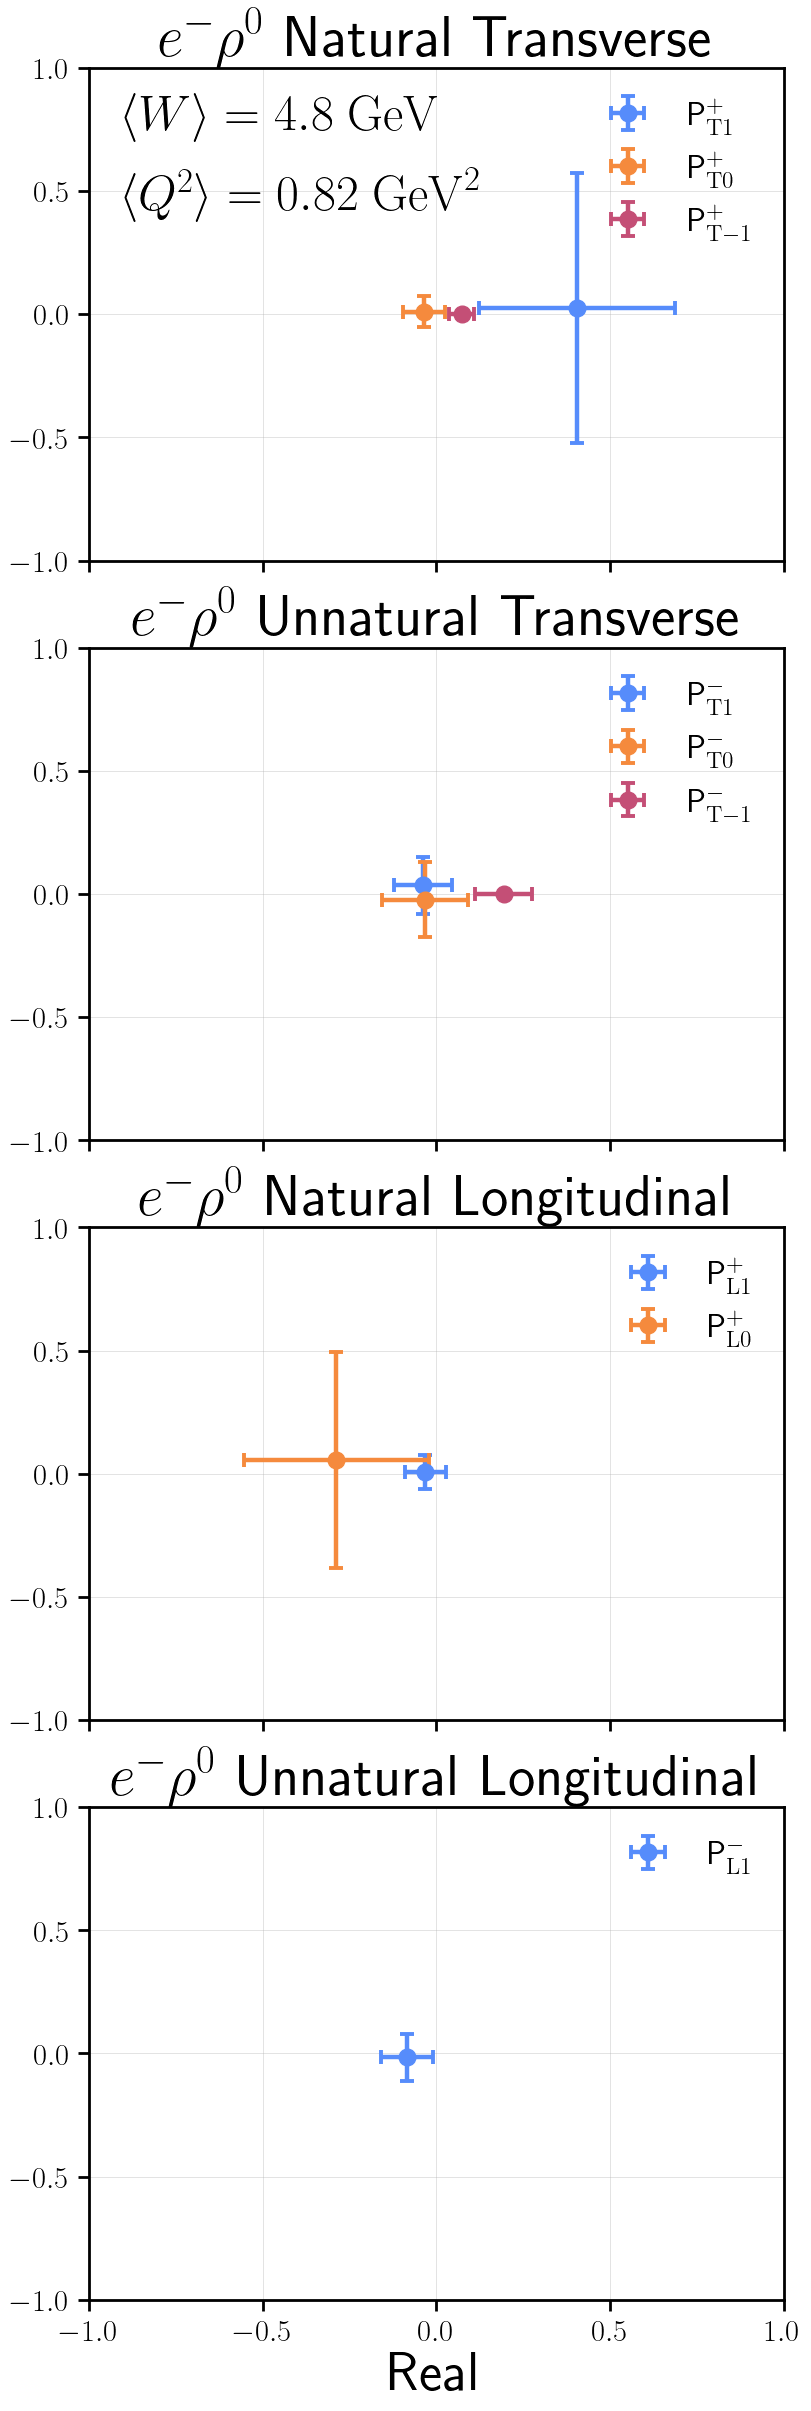

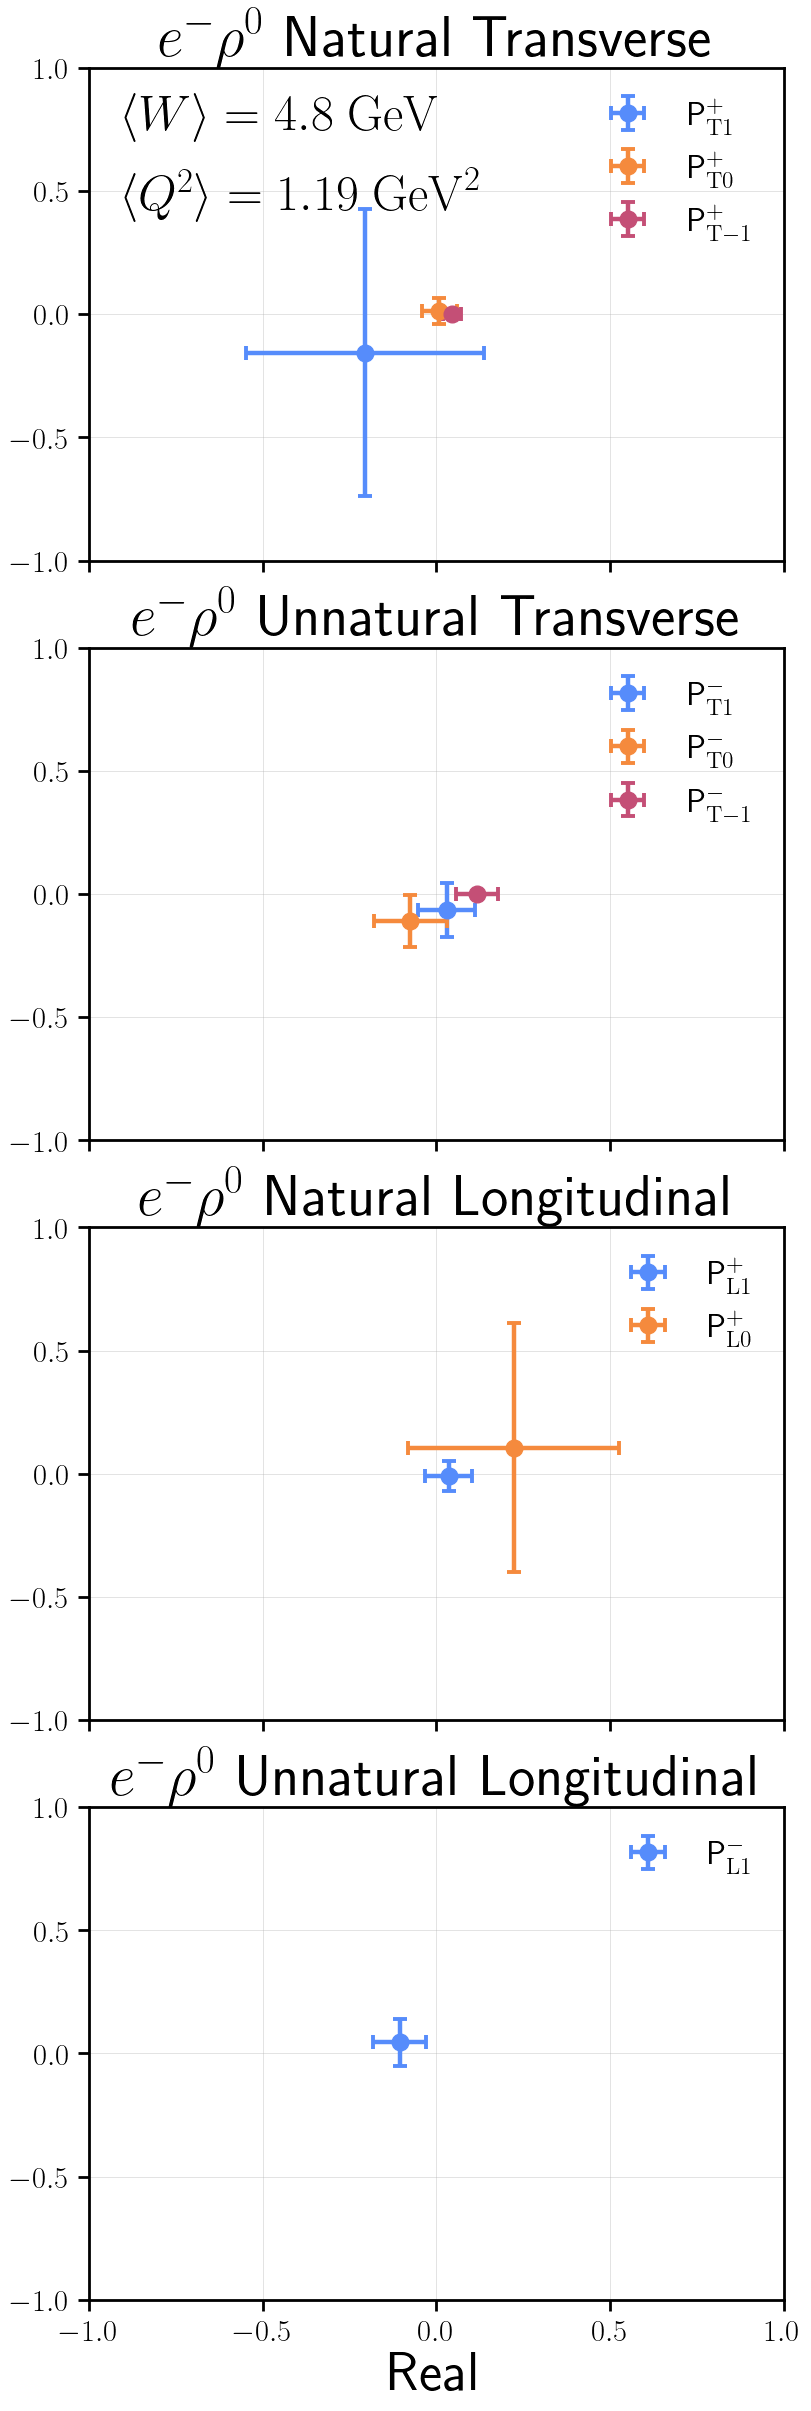

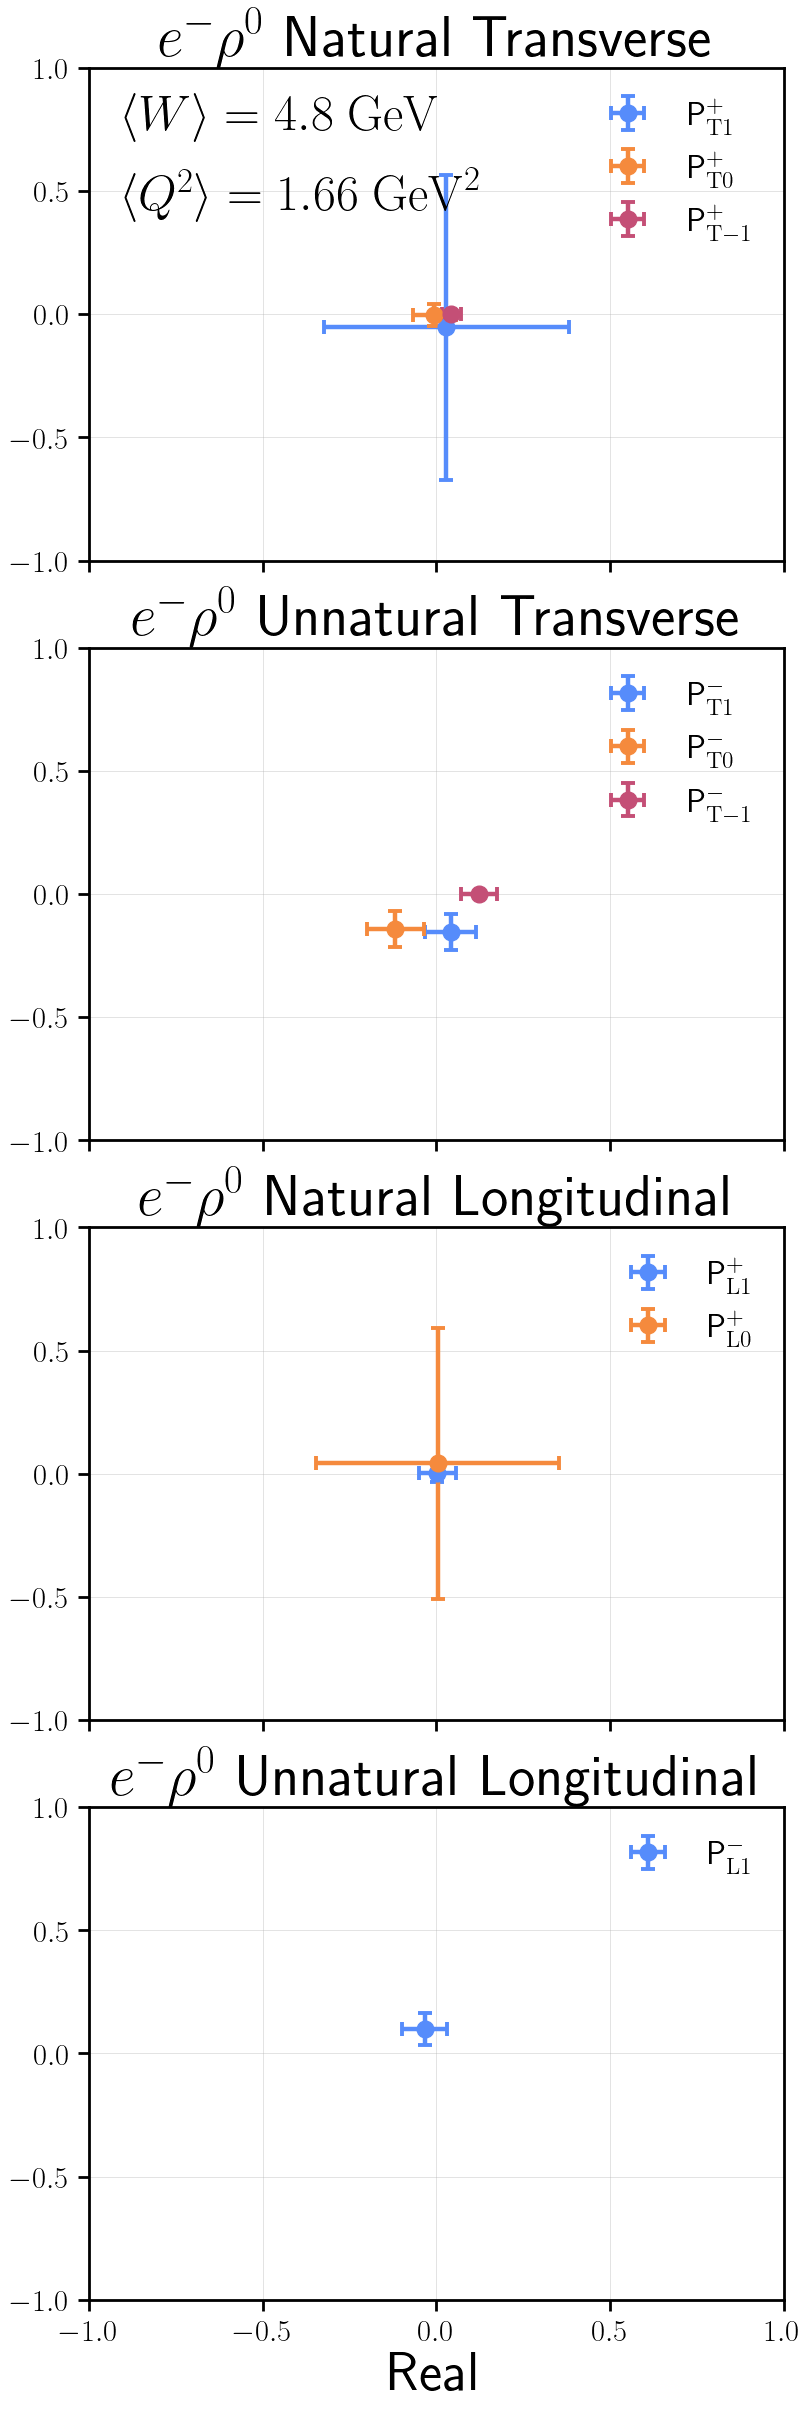

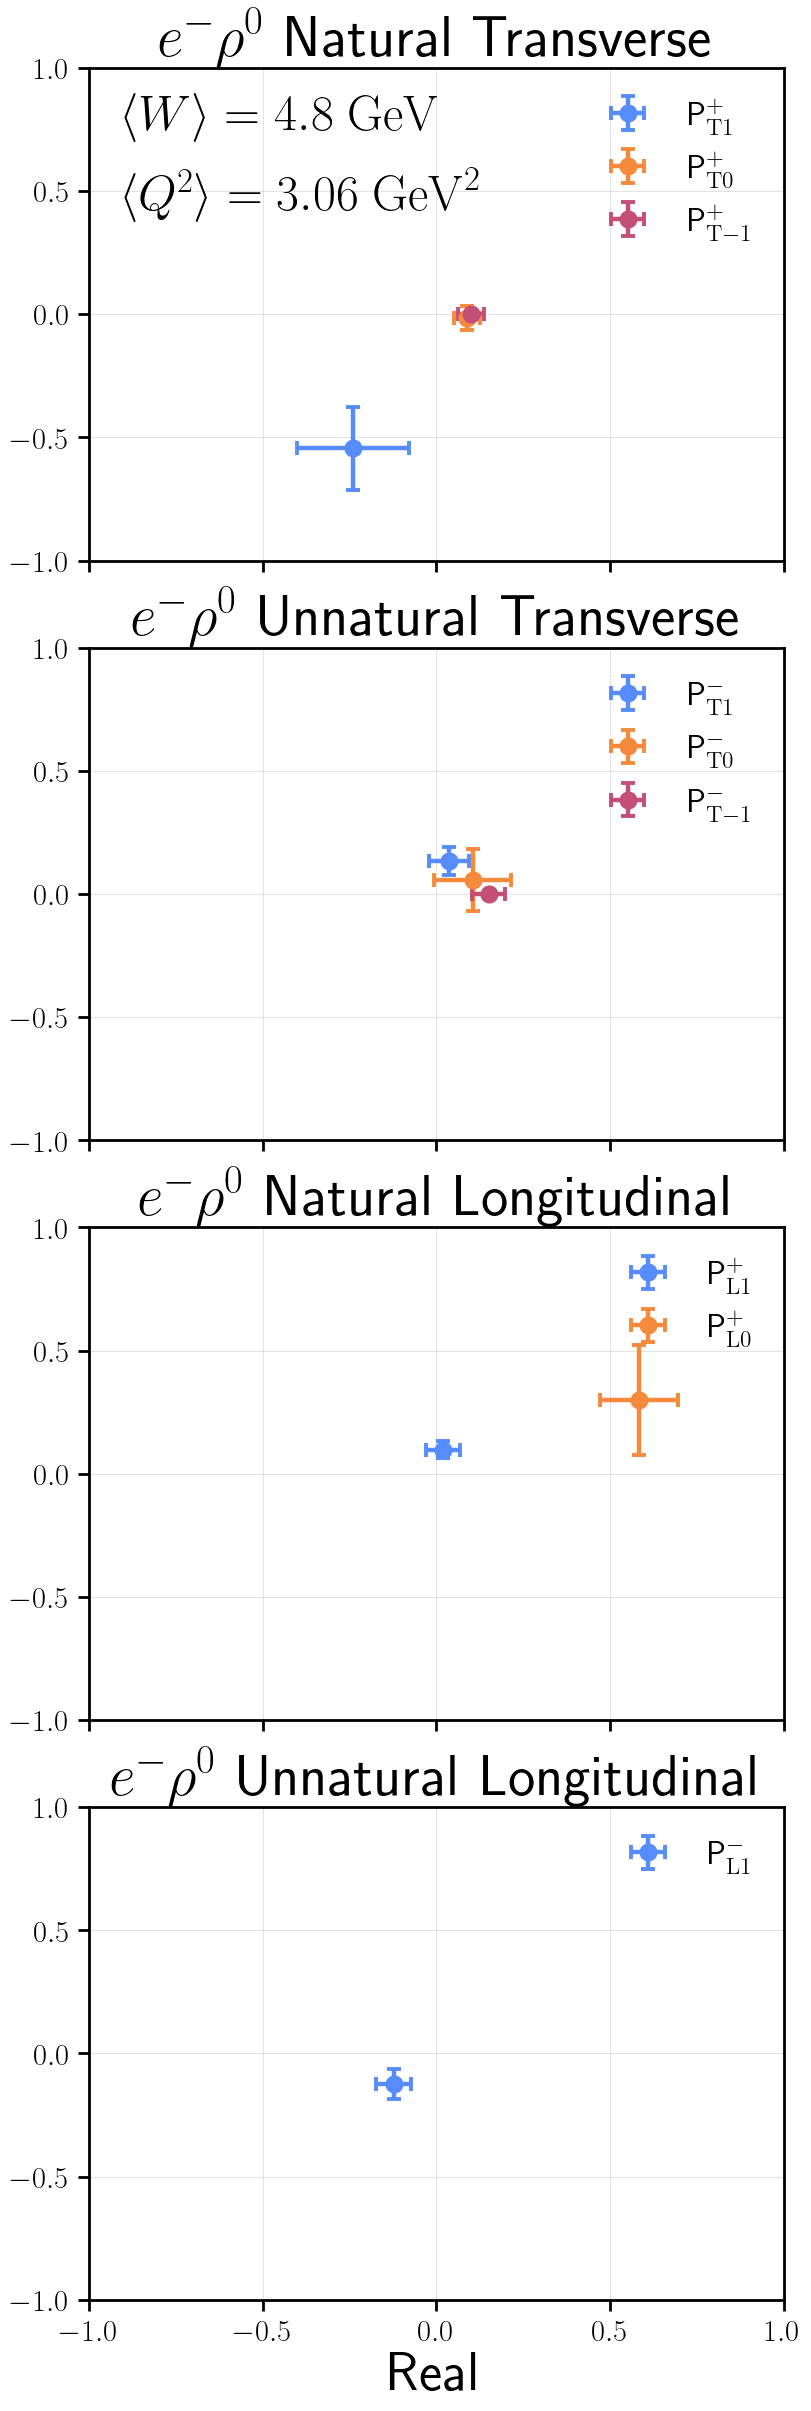

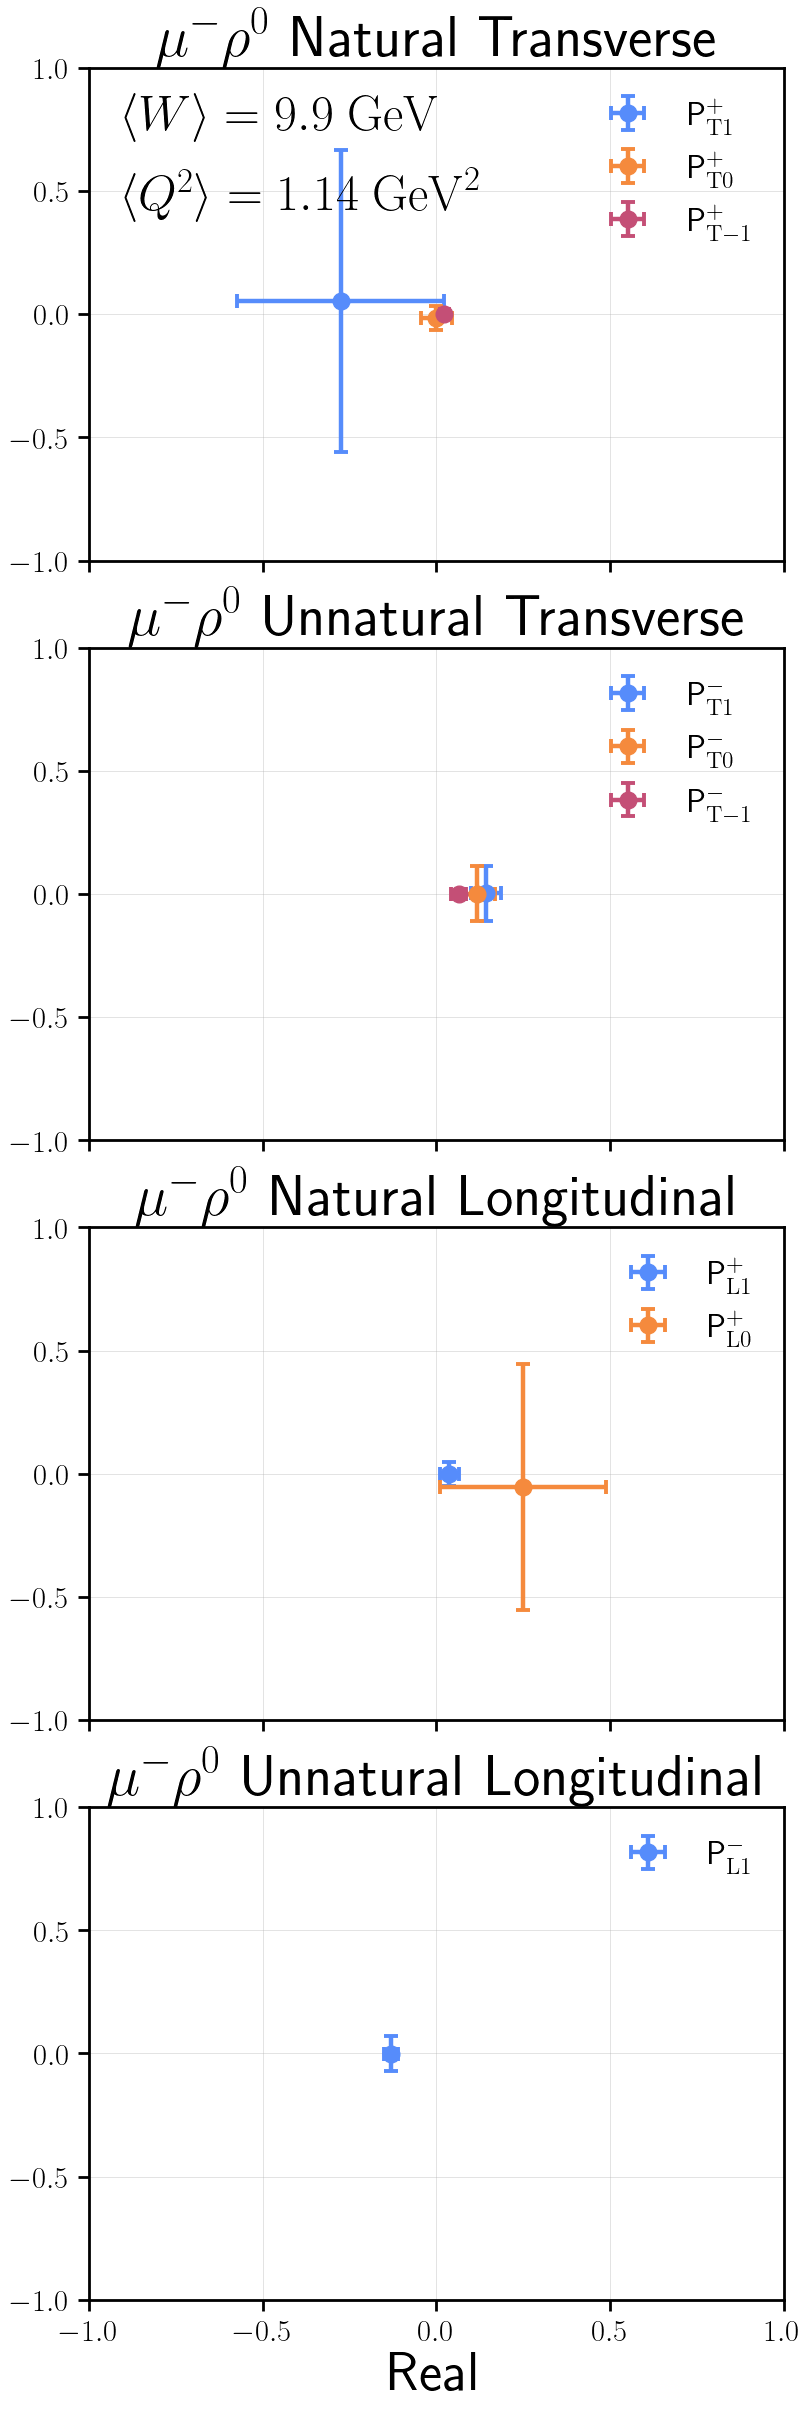

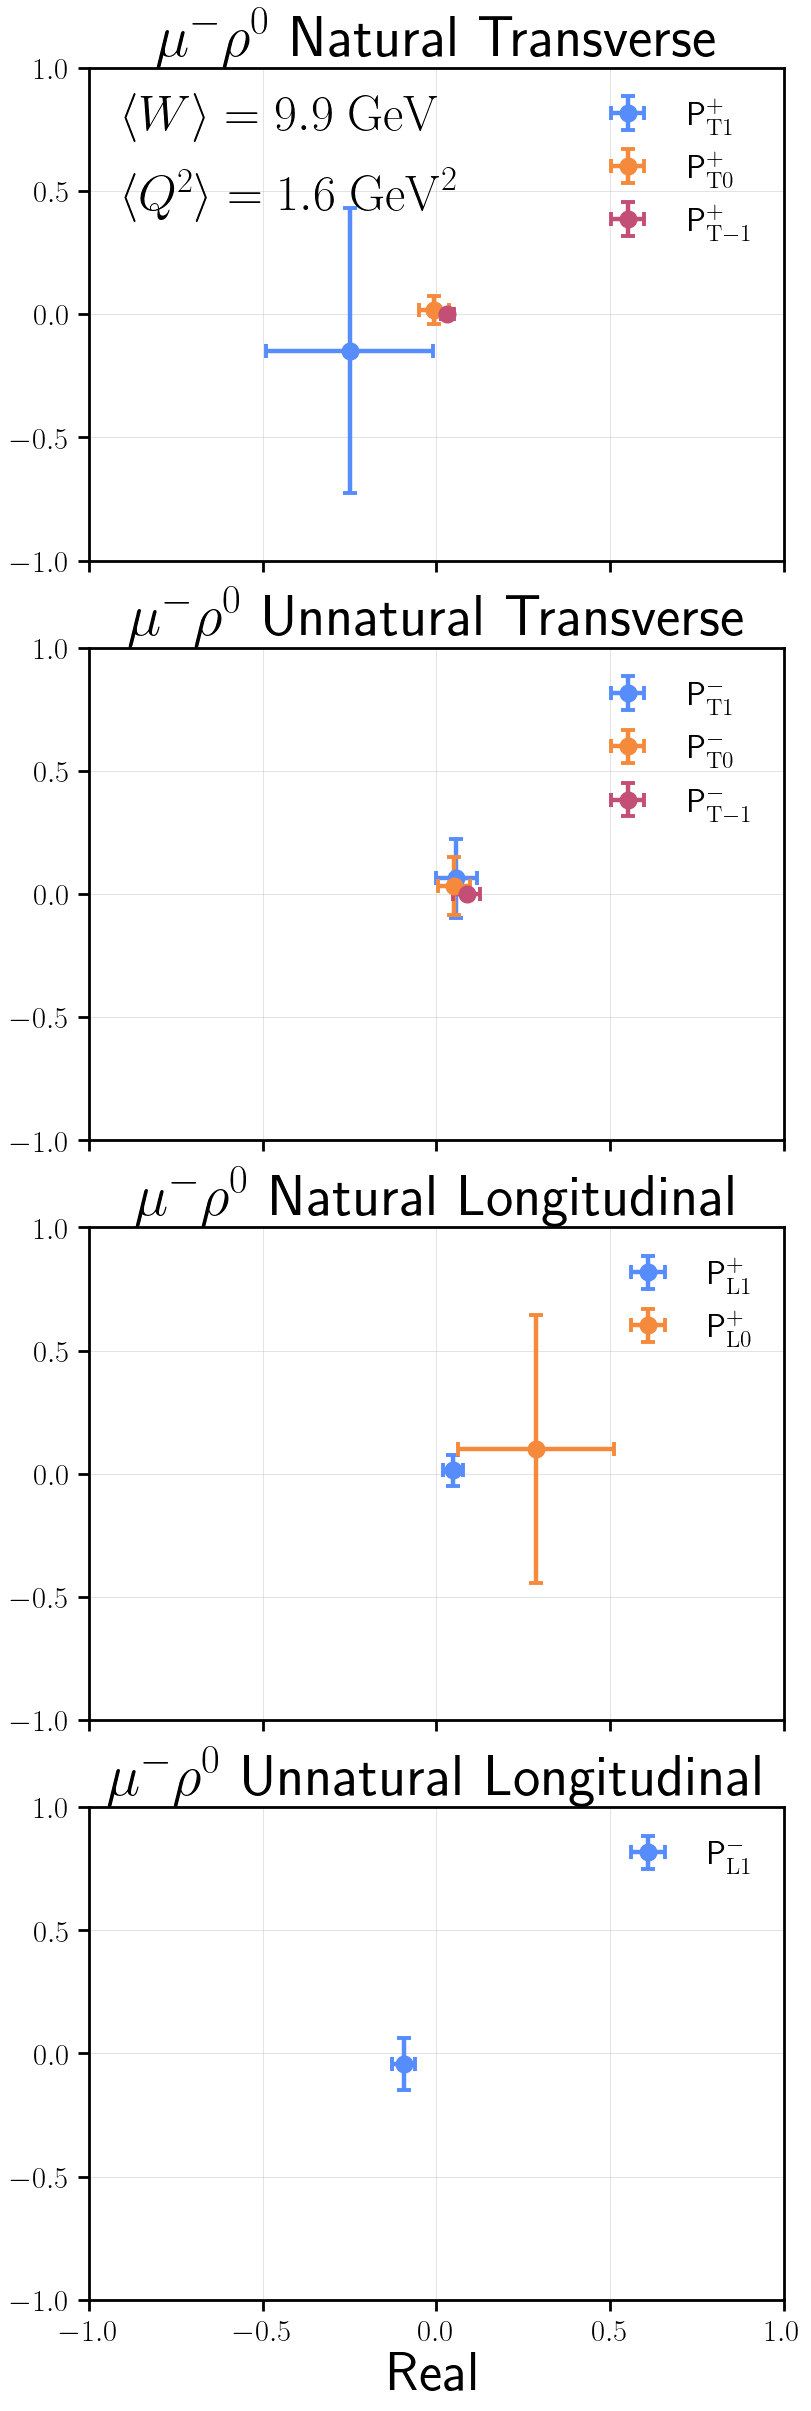

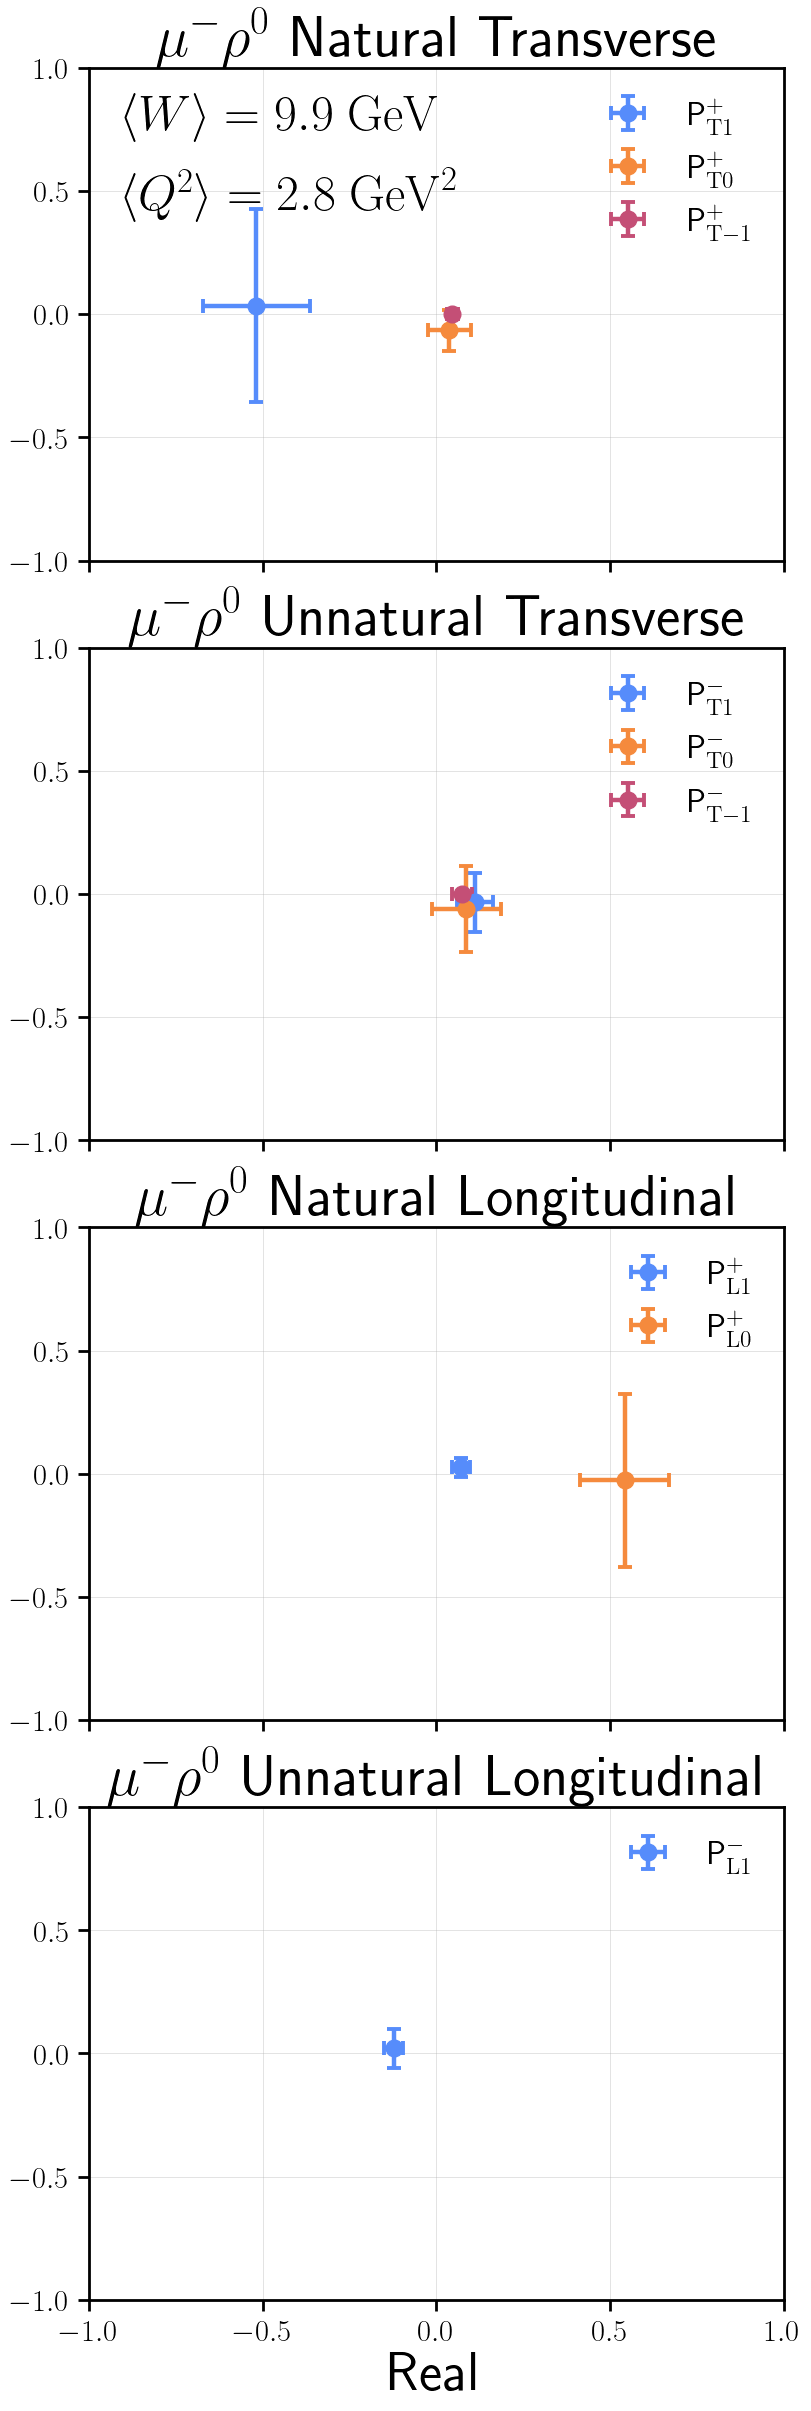

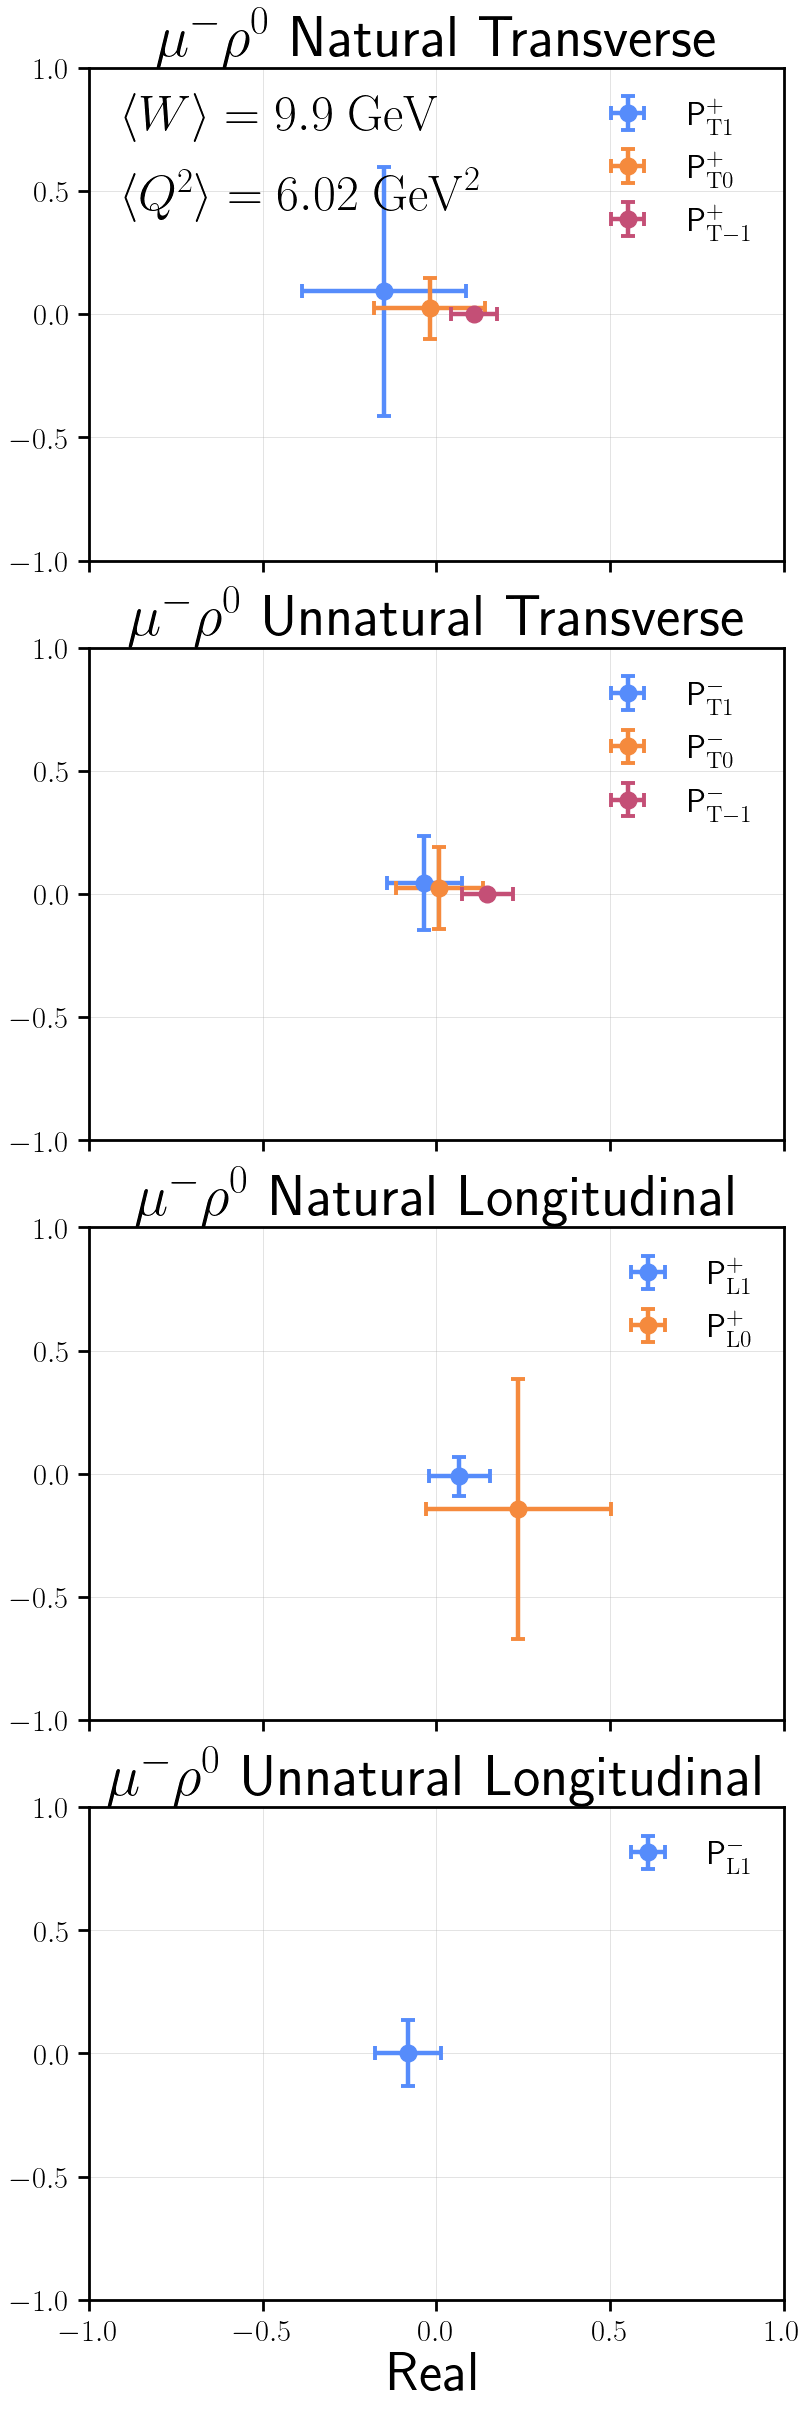

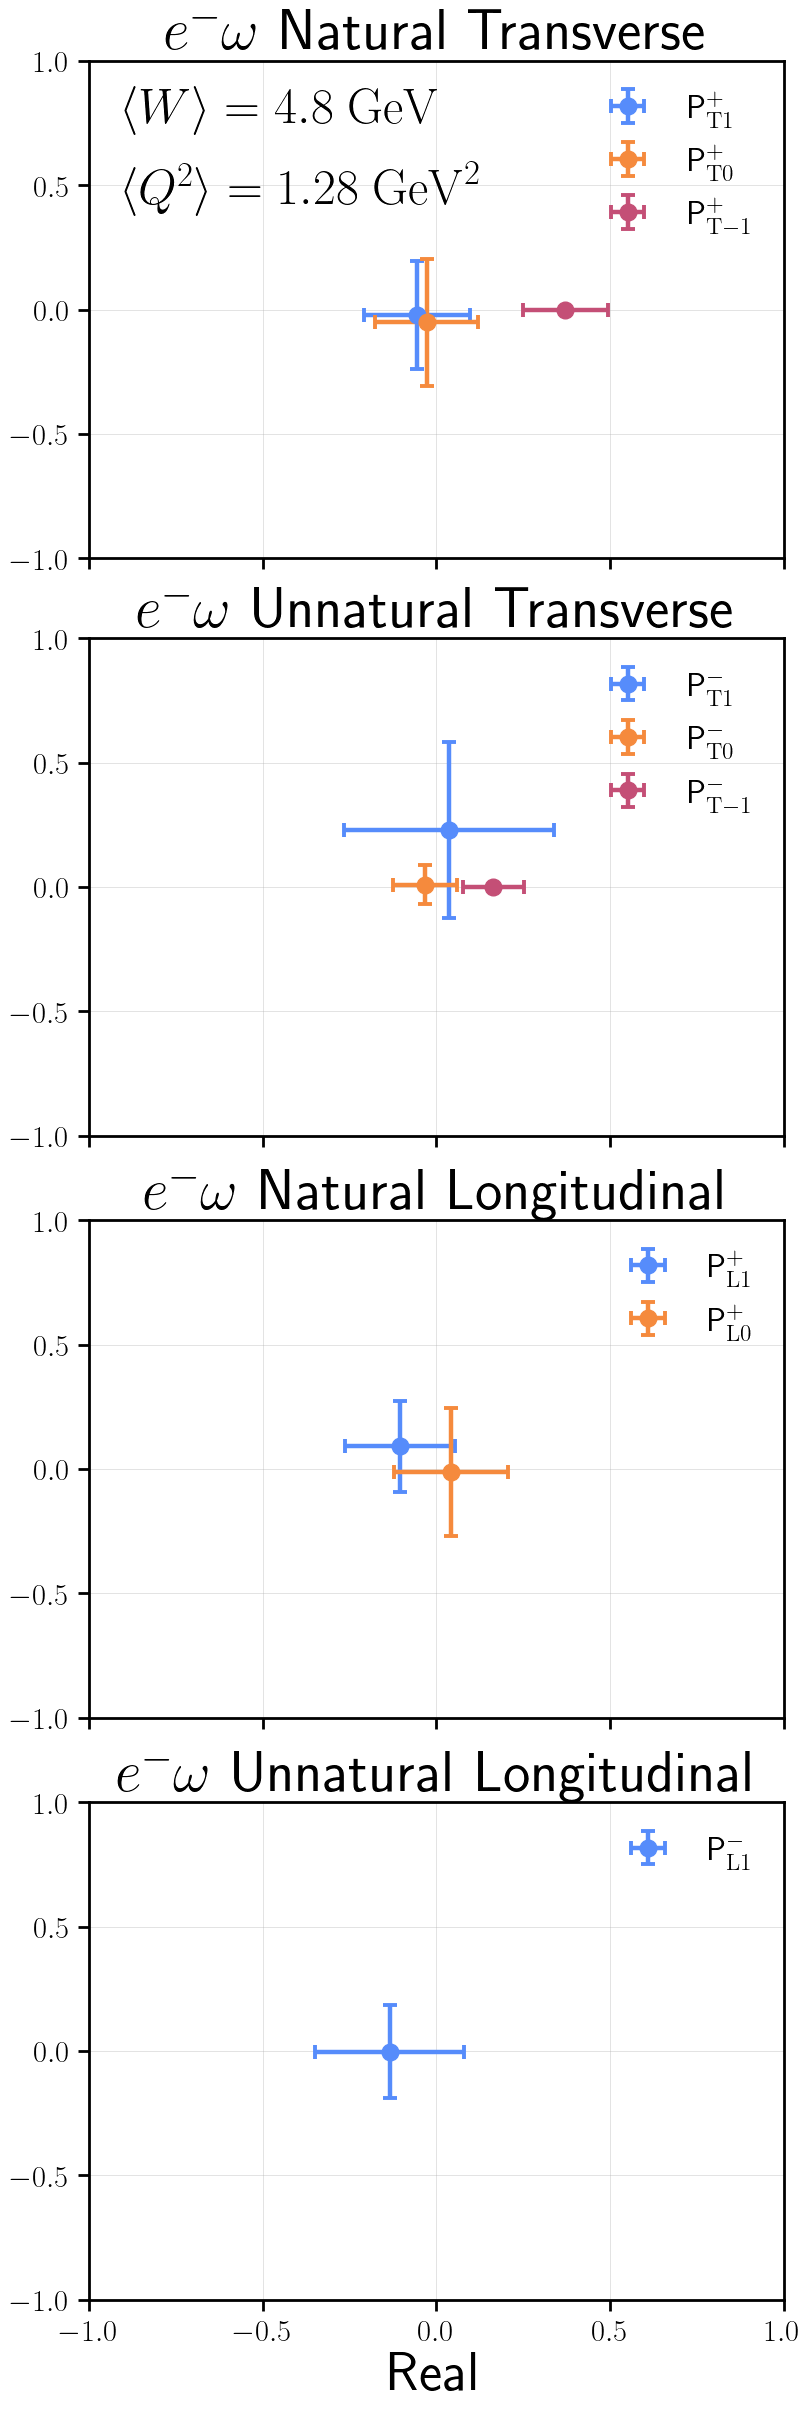

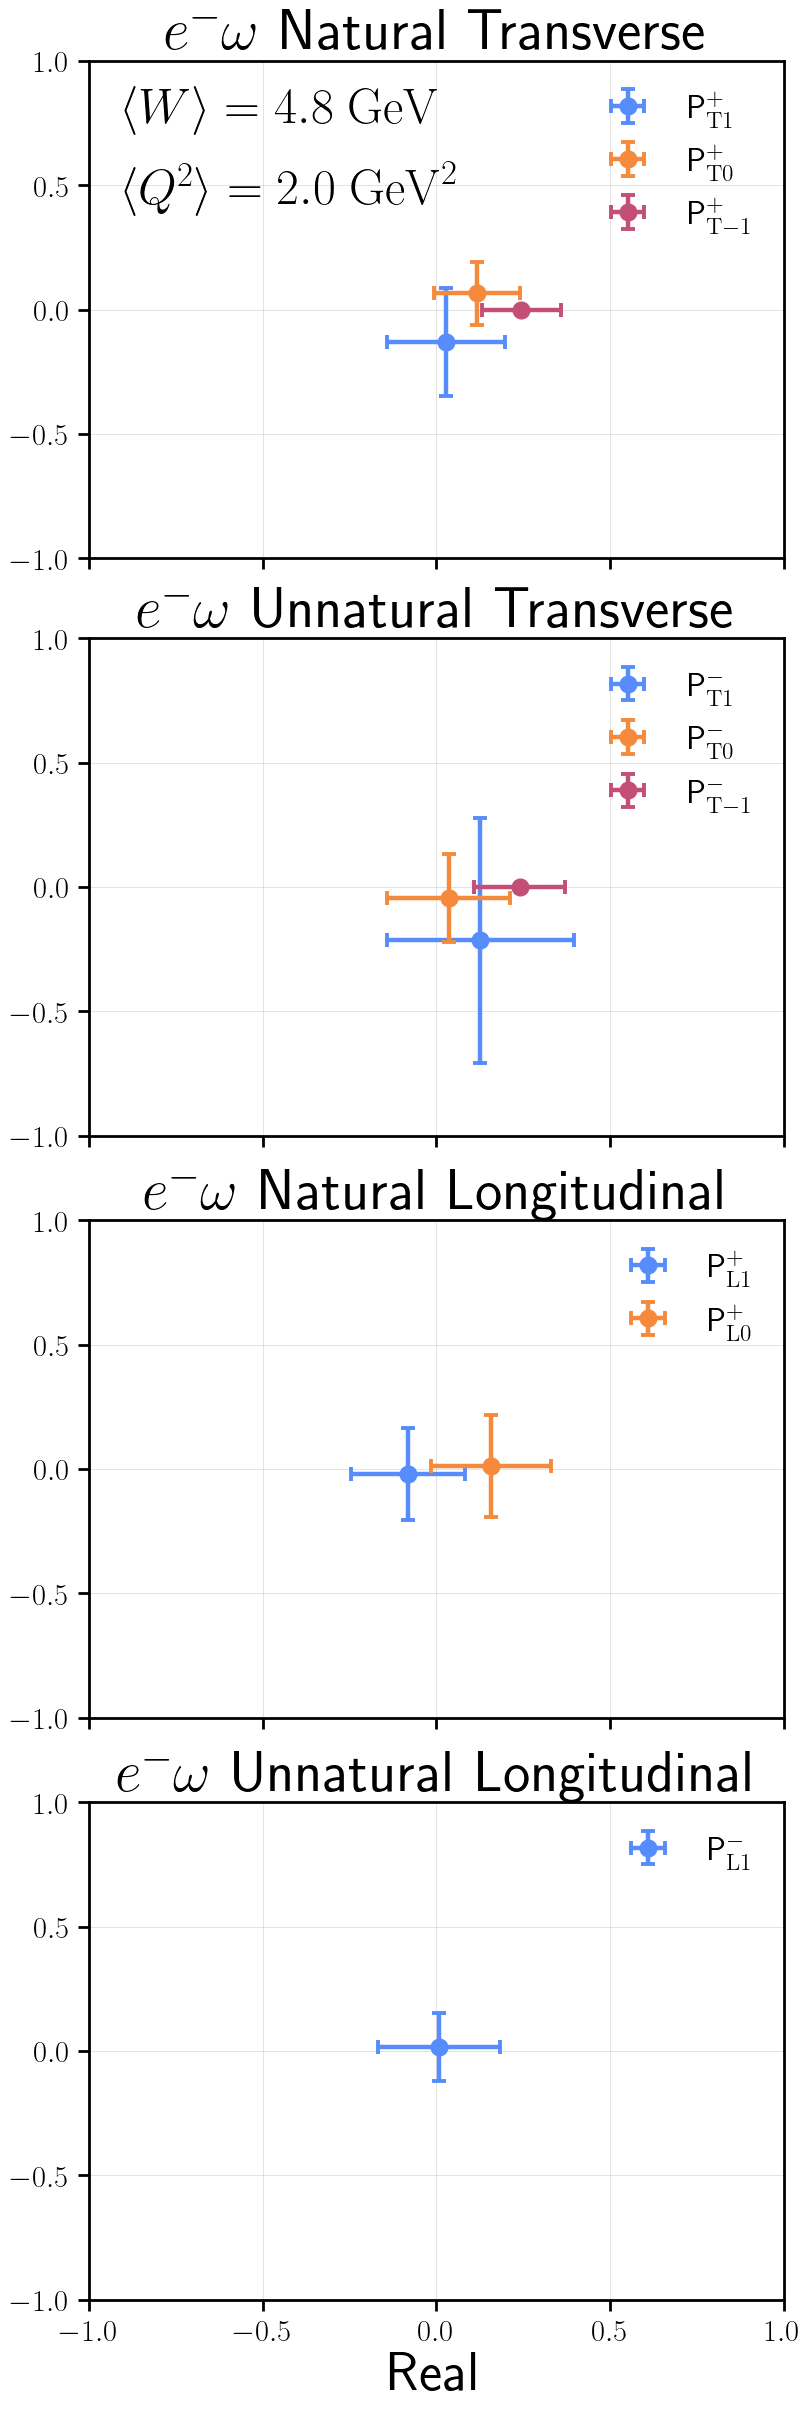

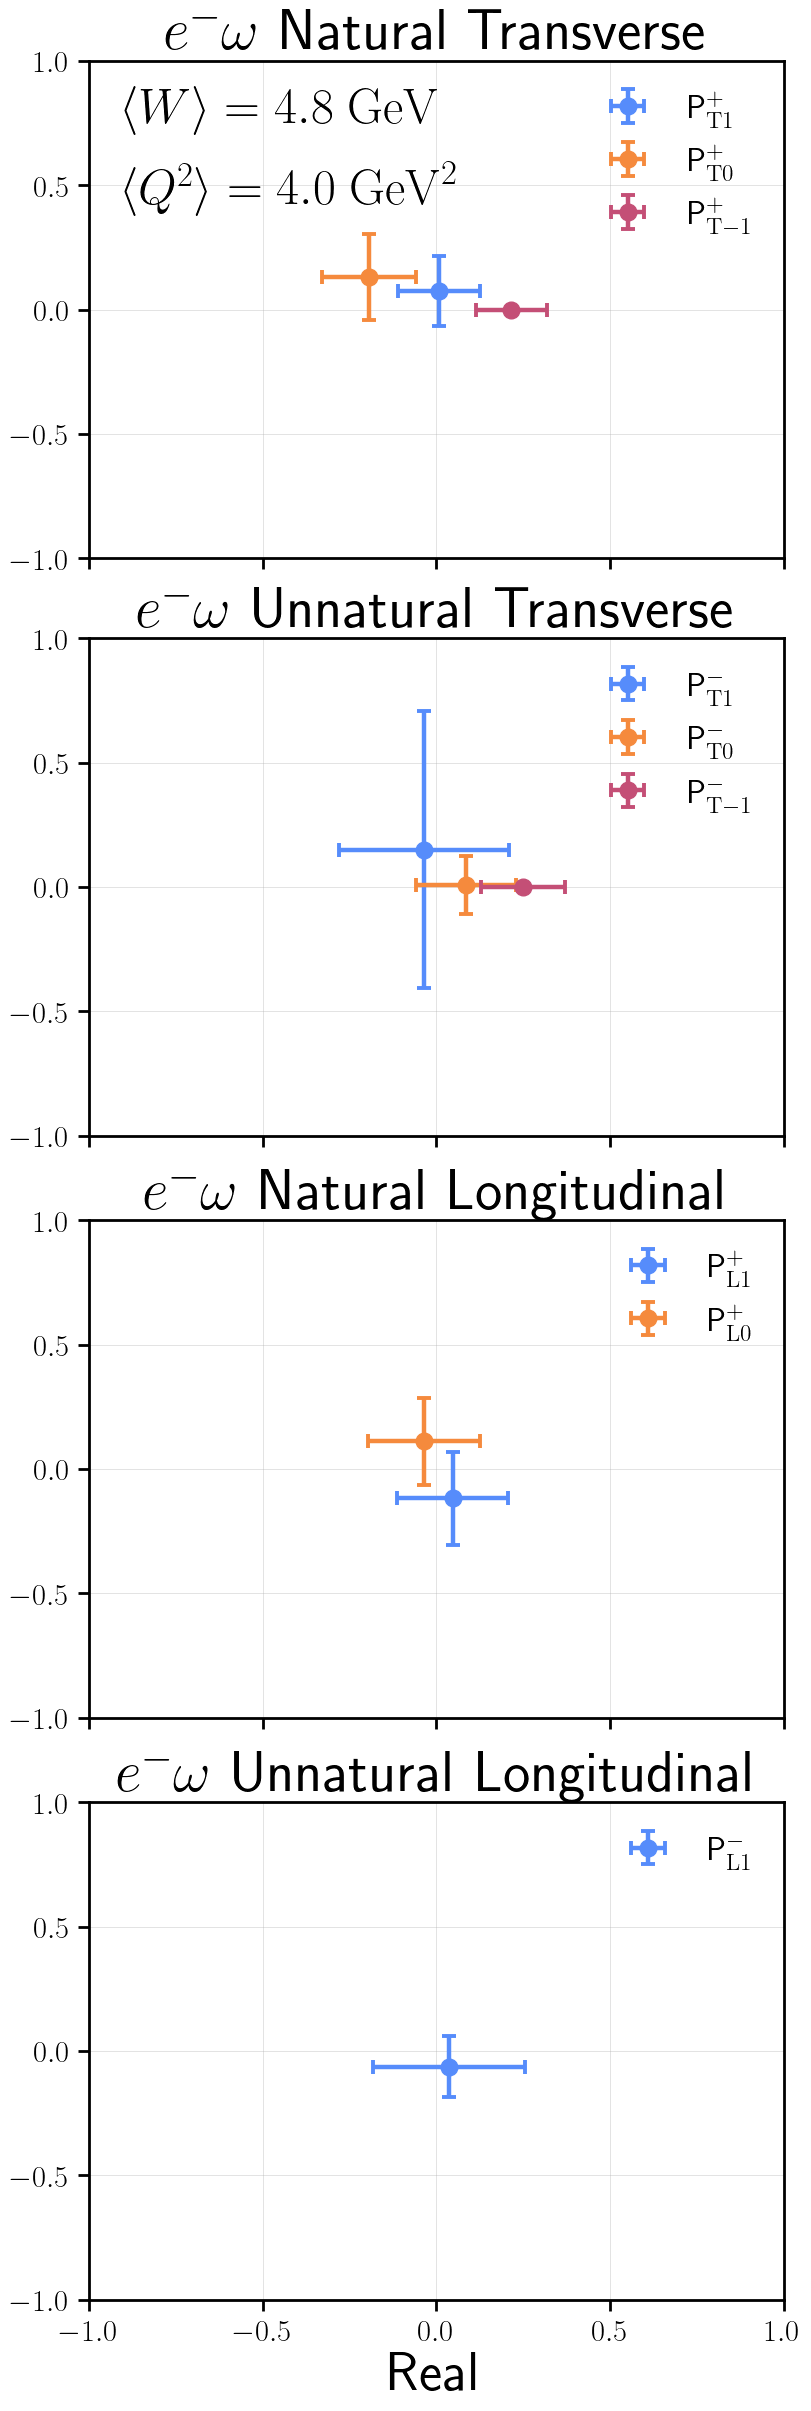

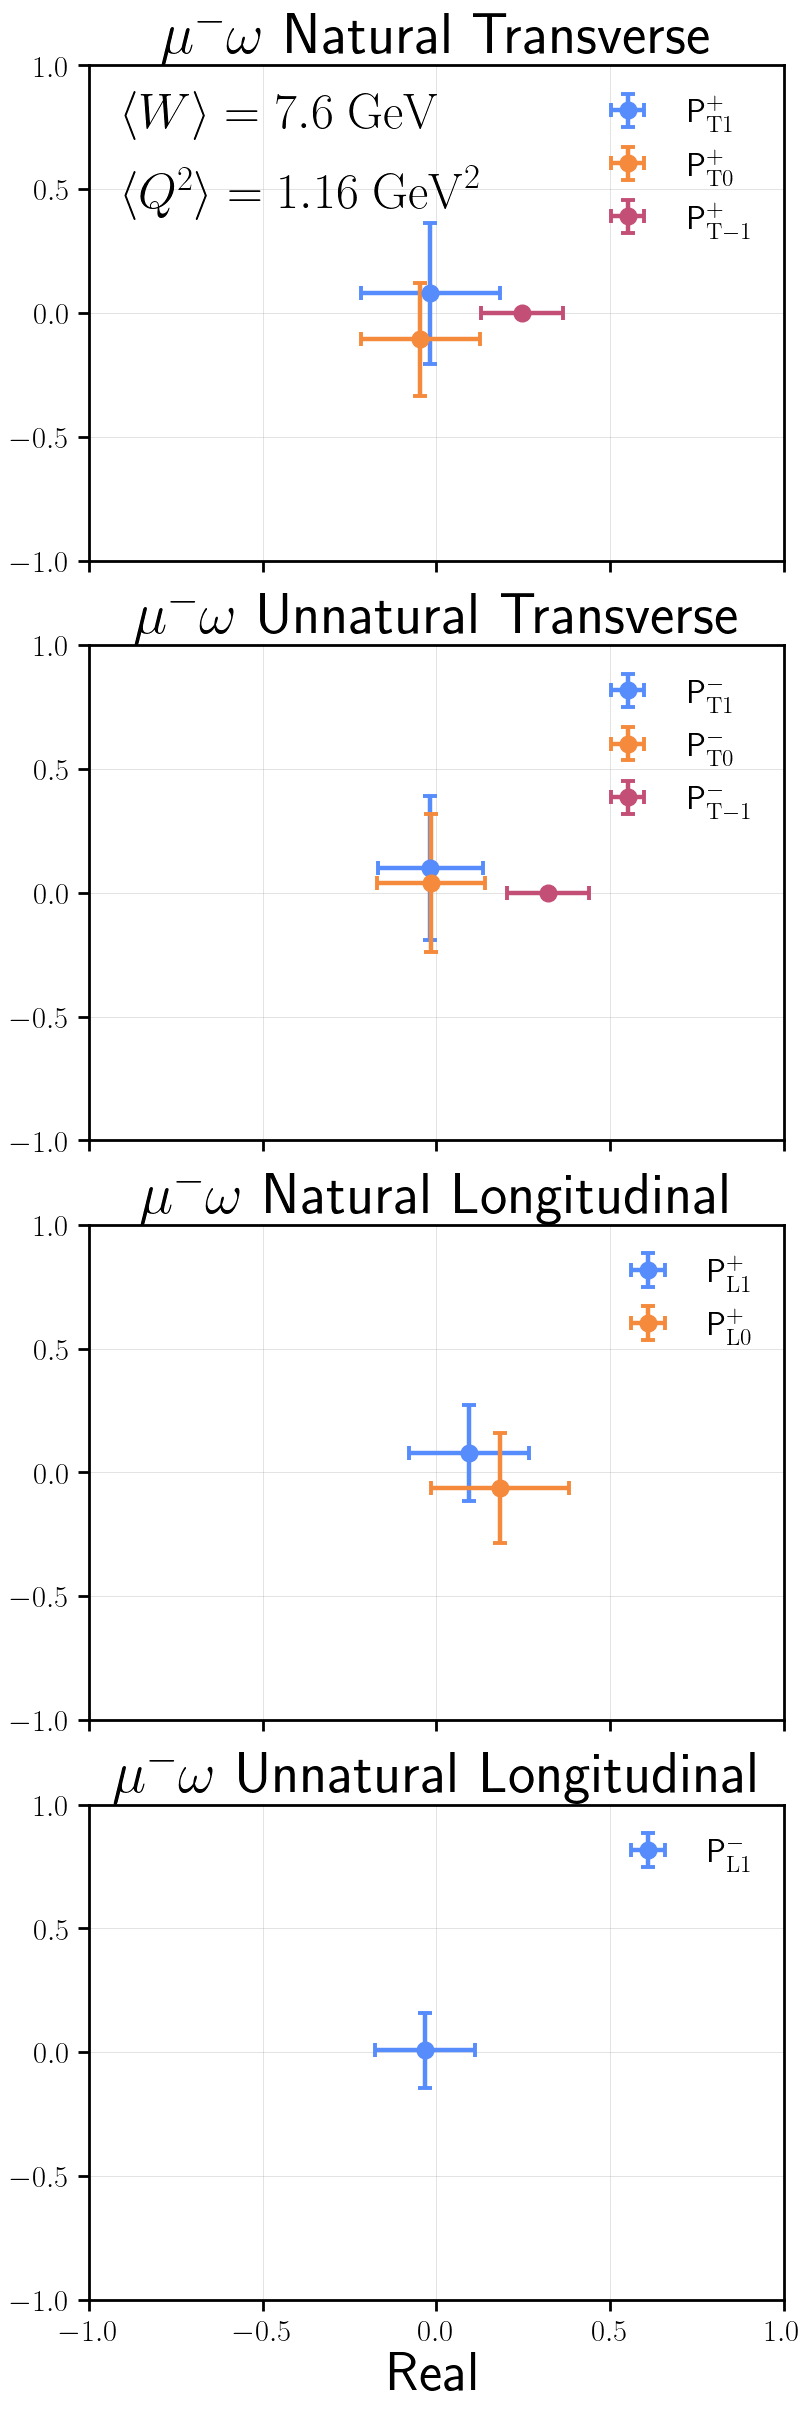

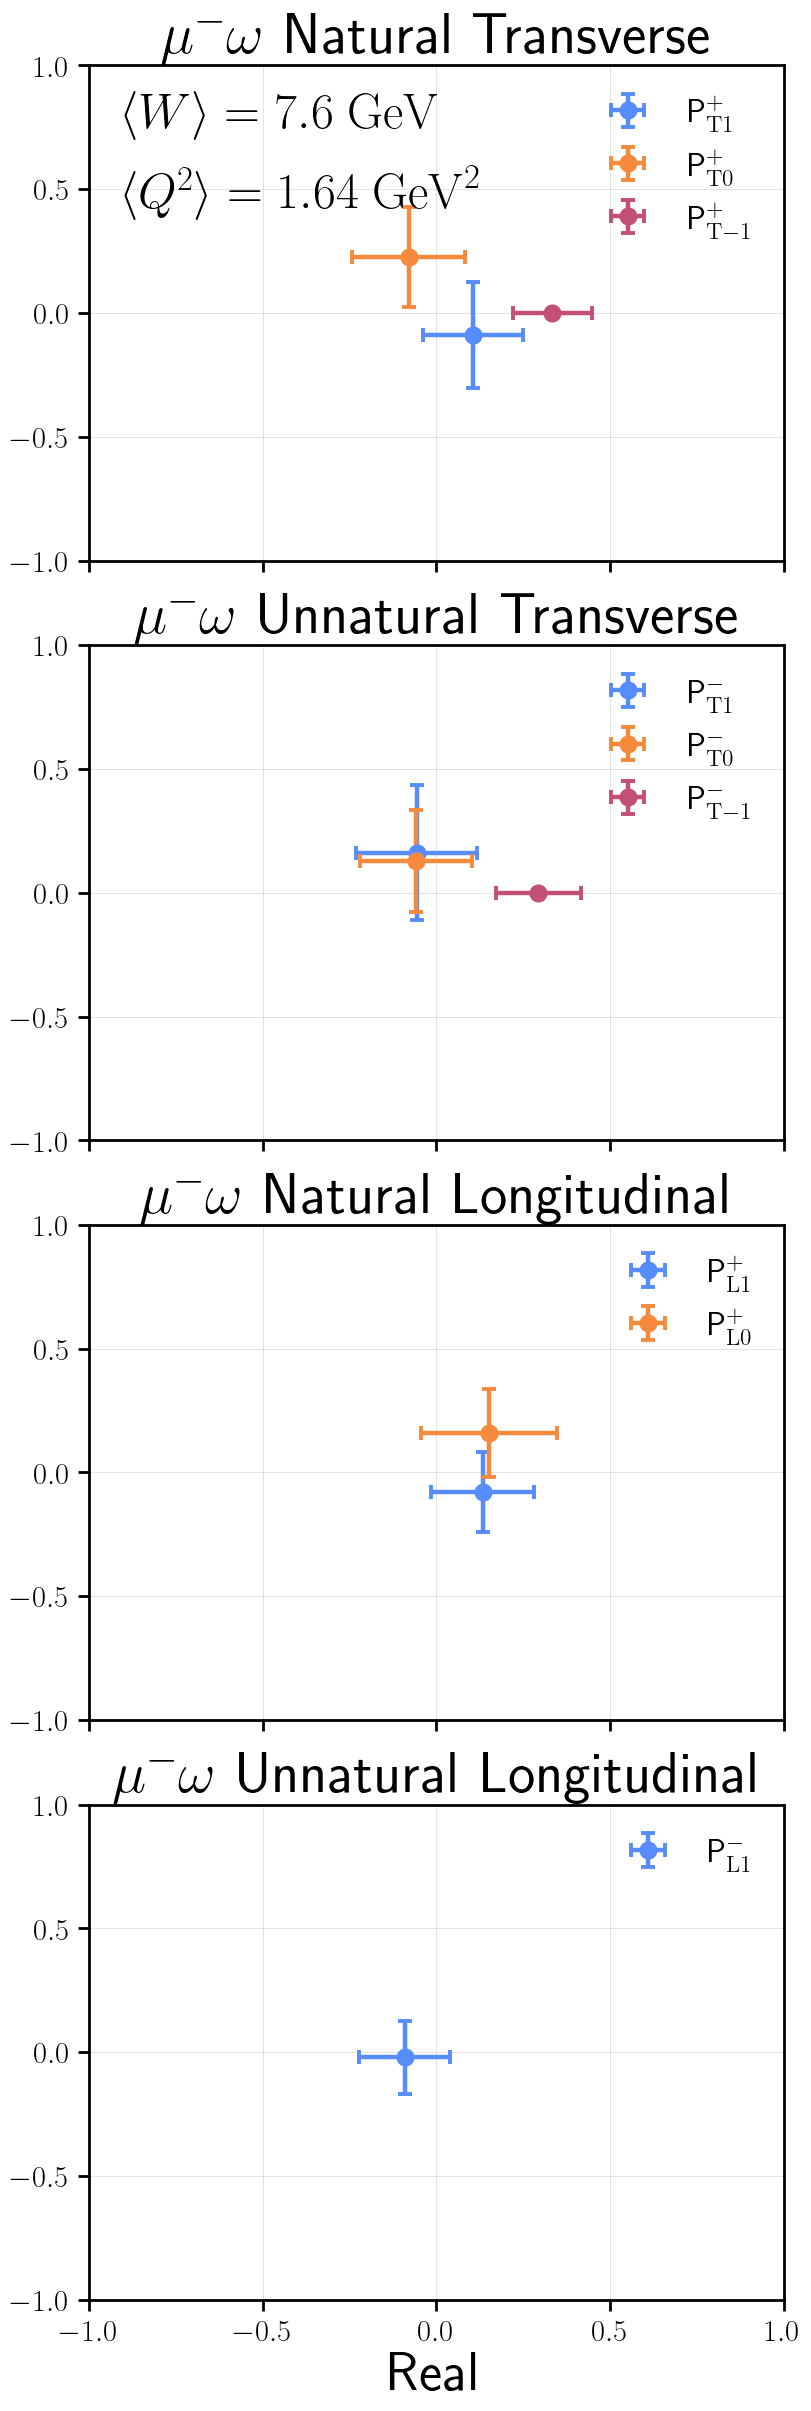

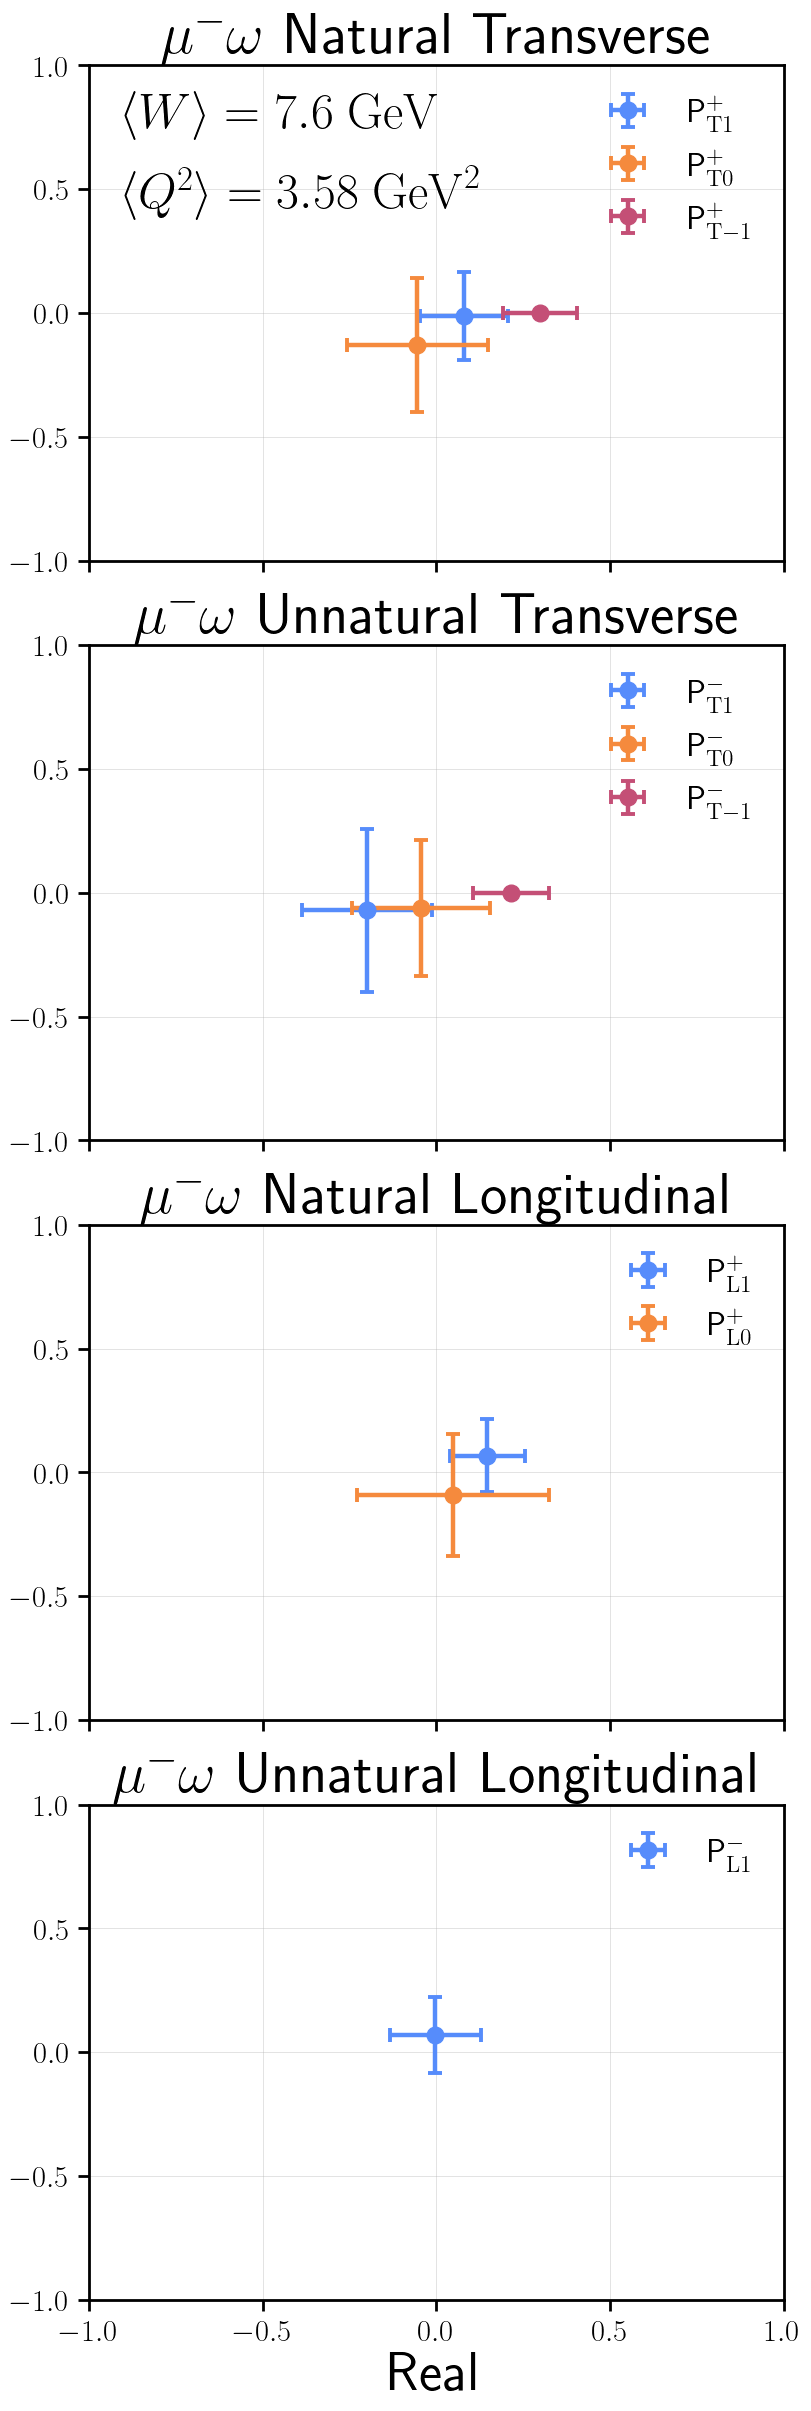

In [21]:
titles = ["Natural Transverse", "Unnatural Transverse", "Natural Longitudinal" ,"Unnatural Longitudinal"]
legends = ["$l=1$, $m=1$", "$l=1$, $m=0$","$l=1$, $m=-1$","$l=0$, $m=0$"]
# PLOT ALL THE RESULTS IN ELLIPTICAL WAY (with bootstrap)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

for r in range(4):
    for i in range(bin_size[r]):
        df = ROOT.RDataFrame(
            "PartialWaves",
            "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/"
            + filenames[r] + "_bootstrap_" + str(i) + ".root"
        )

        ## Define columns here
        df = df.Define("a_L_1_m1", "-1*a_L_1_1")
        df = df.Define("b_L_1_m1", "b_L_1_1")
        df = df.Define("aphi_L_1_m1", "aphi_L_1_1")
        df = df.Define("bphi_L_1_m1", "bphi_L_1_1")
        arrays_mag = df.AsNumpy(columns=cols_mag)
        arrays_phase = df.AsNumpy(columns=cols_phase)

        # All arrays have the same length
        N = np.shape(arrays_mag[cols_mag[0]])[0]

        fig, axs = plt.subplots(4, 1, figsize=(8, 24), sharex=True, constrained_layout=True)
        # axs[0, 0].text(
        #     0.05, 0.95,
        #     "$N_{{min}} = {0}$".format(N),
        #     fontsize=22,
        #     verticalalignment='top',
        #     transform=axs[0, 0].transAxes,
        #     bbox=props
        # )

        axs[0].text(
            0.05, 0.8,
            "$\\langle Q^2 \\rangle =  {0}\\;\\mathrm{{GeV}}^2$".format(Q2[r, i]),
            fontsize=36,
            verticalalignment='top',
            transform=axs[0].transAxes,
        )
        axs[0].text(
            0.05, 0.95,
            "$\\langle W\\rangle = {0}\\;\\mathrm{{GeV}}$".format(W[r]),
            fontsize=36,
            verticalalignment='top',
            transform=axs[0].transAxes,
        )

        for j in range(4):
            for k in range(4):
                if k==3:
                    continue
                # Add better logic for this
                if  (cols_mag[k + 4 * j][0] == "b" and cols_mag[k + 4 * j][2] == "L" and cols_mag[k + 4 * j][-1] == "0") or (cols_mag[k + 4 * j][2] == "L" and cols_mag[k + 4 * j][-2]=="m"):
                    continue

                y = arrays_mag[cols_mag[k + 4 * j]]
                x = arrays_phase[cols_phase[k + 4 * j]]

                re = y * np.cos(x)
                im = y * np.sin(x)

                mean_y = np.mean(y)
                err_y = np.std(y)

                mean_x = circular_mean(x)
                err_x = circular_std(x)

                mean_re = np.mean(re)
                err_re = np.std(re)

                mean_im = np.mean(im)
                err_im = np.std(im)

                # axs[j, 0].errorbar(
                #     mean_x, mean_y,
                #     xerr=err_x, yerr=err_y,
                #     fmt='o', markersize=12, elinewidth=3.2,
                #     capsize=5, capthick=2.8
                # )
                # axs[j, 0].axis(xmin=-np.pi, xmax=np.pi, ymin=-0.05, ymax=1)

                axs[j].errorbar(
                    mean_re, mean_im,
                    xerr=err_re, yerr=err_im,
                    fmt='o', markersize=12, elinewidth=3.2,
                    capsize=5, capthick=2.8,
                    label=ToWave(cols_mag[k + 4*j])
                )
                axs[j].axis(xmin=-1, xmax=1, ymin=-1, ymax=1)

            # axs[j, 0].set_ylabel("Magnitude", fontsize=26)
            #axs[j].set_ylabel("Imaginary", fontsize=26)

            if j == 3:
                # axs[j, 0].set_xlabel("Phase", fontsize=26)
                axs[j].set_xlabel("Real")



            axs[j].set_title(channel_titles[r]+" "+titles[j])
            axs[j].set_yticks([-1,-0.5,0,0.5,1])
            axs[j].set_xticks([-1,-0.5,0,0.5,1])
            axs[j].grid(True, alpha=0.5)
            axs[j].legend(loc="upper right", frameon=False, fontsize=24)

            # apply_poster_axis_style(axs[j, 0], labelsize=18)
            apply_poster_axis_style(axs[j], labelsize=22)

        #axs[0].legend(loc="upper right", frameon=True, fontsize=15)
        #fig.suptitle(channel_titles[r] + " Q$^2$ = {0}".format(Q2[r, i]), size=30)
        fig.savefig(
            reaction[r] + "_bootstrap_" + str(i) + "_poster.pdf",
            format='pdf',
            dpi=600,
            transparent=True,
            bbox_inches='tight'
        )
        plt.show()


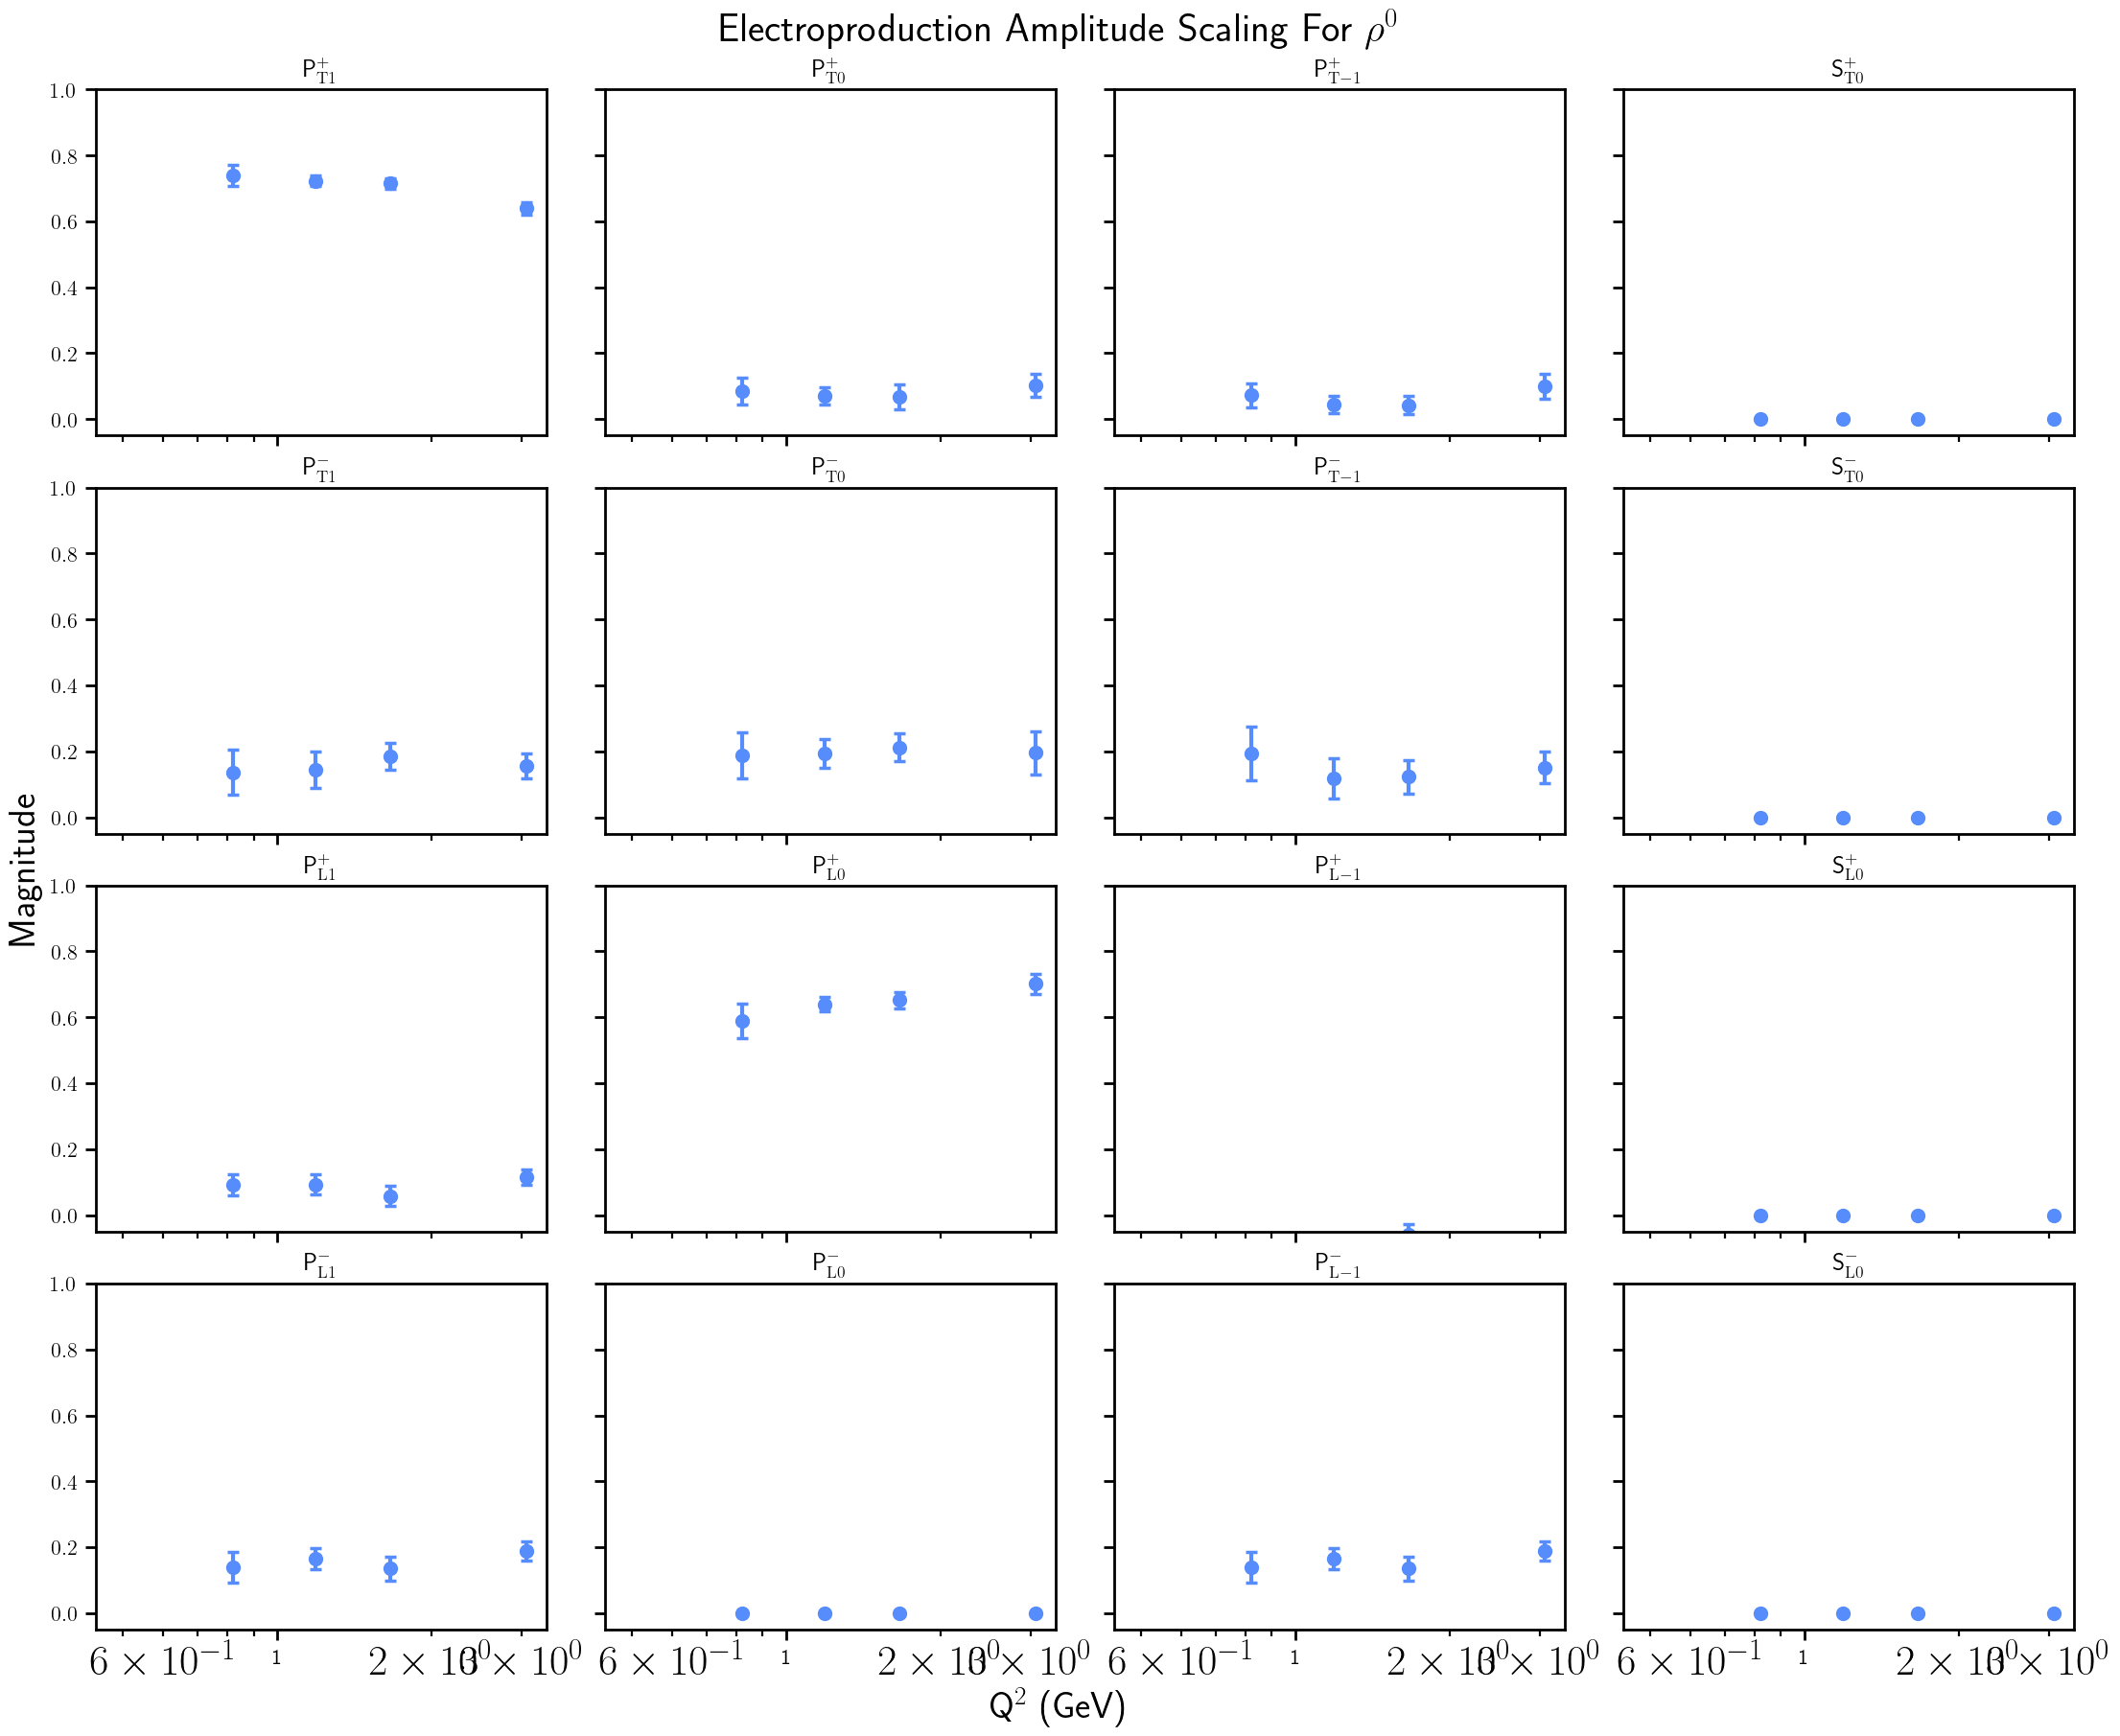

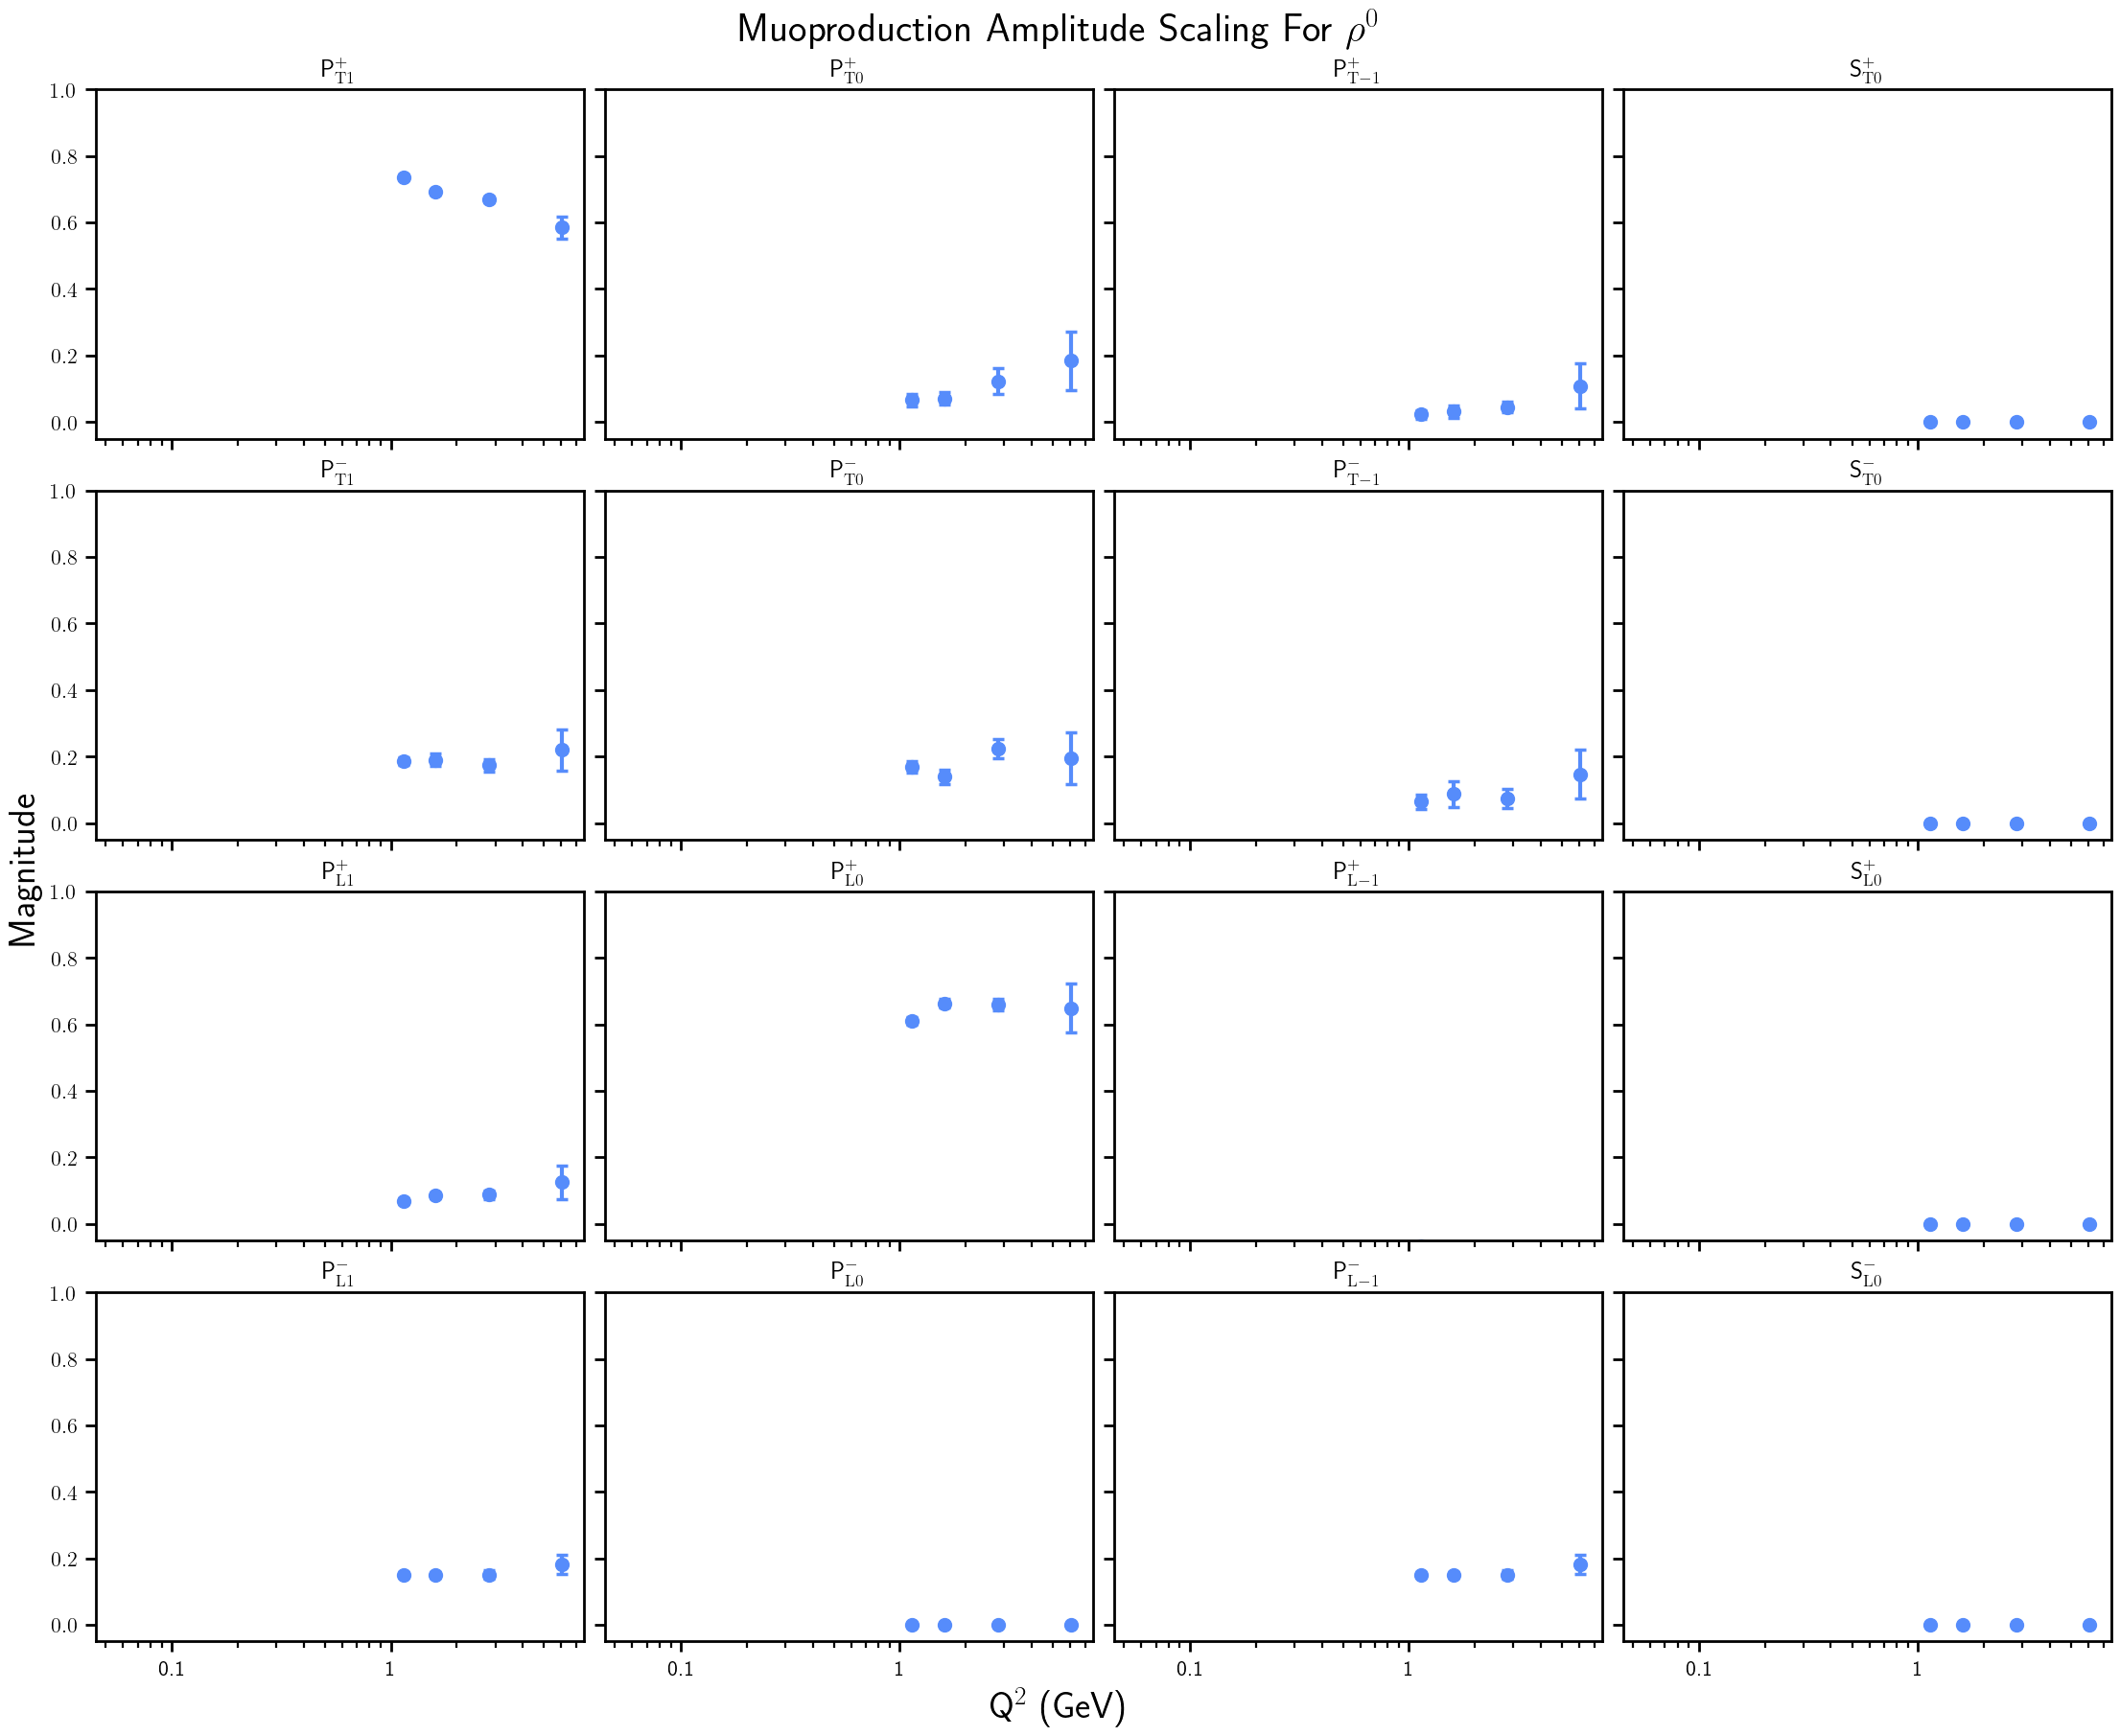

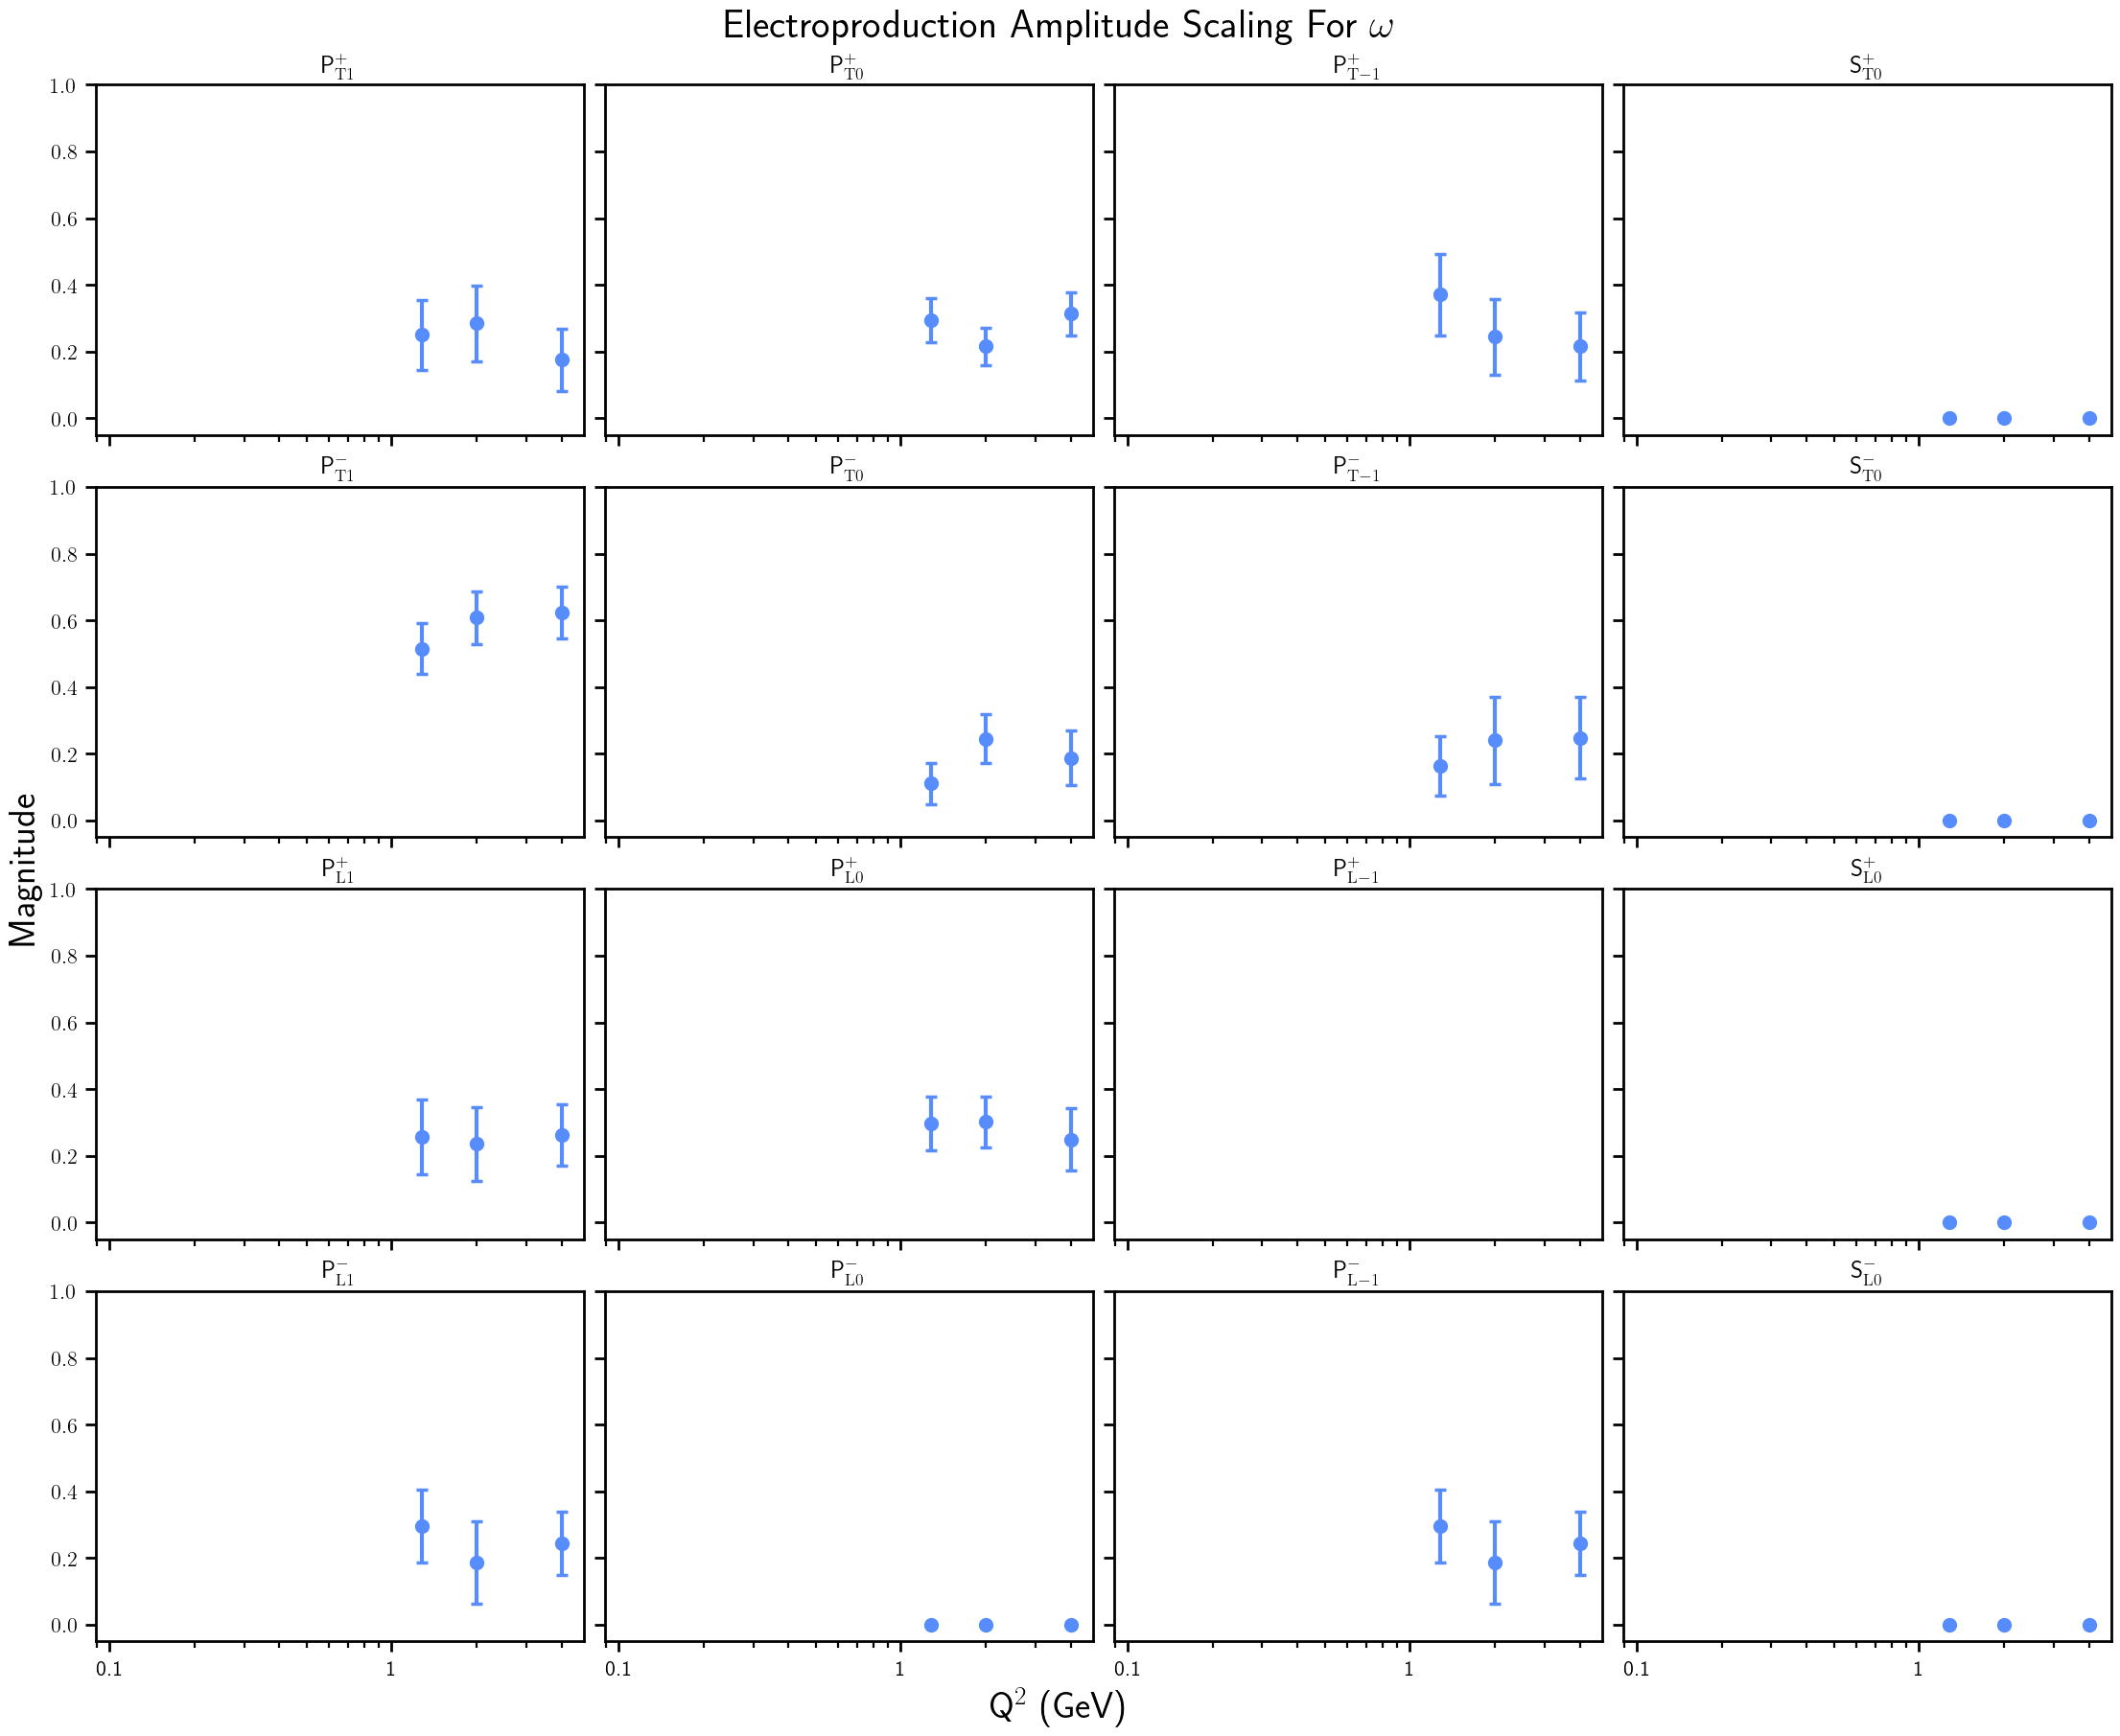

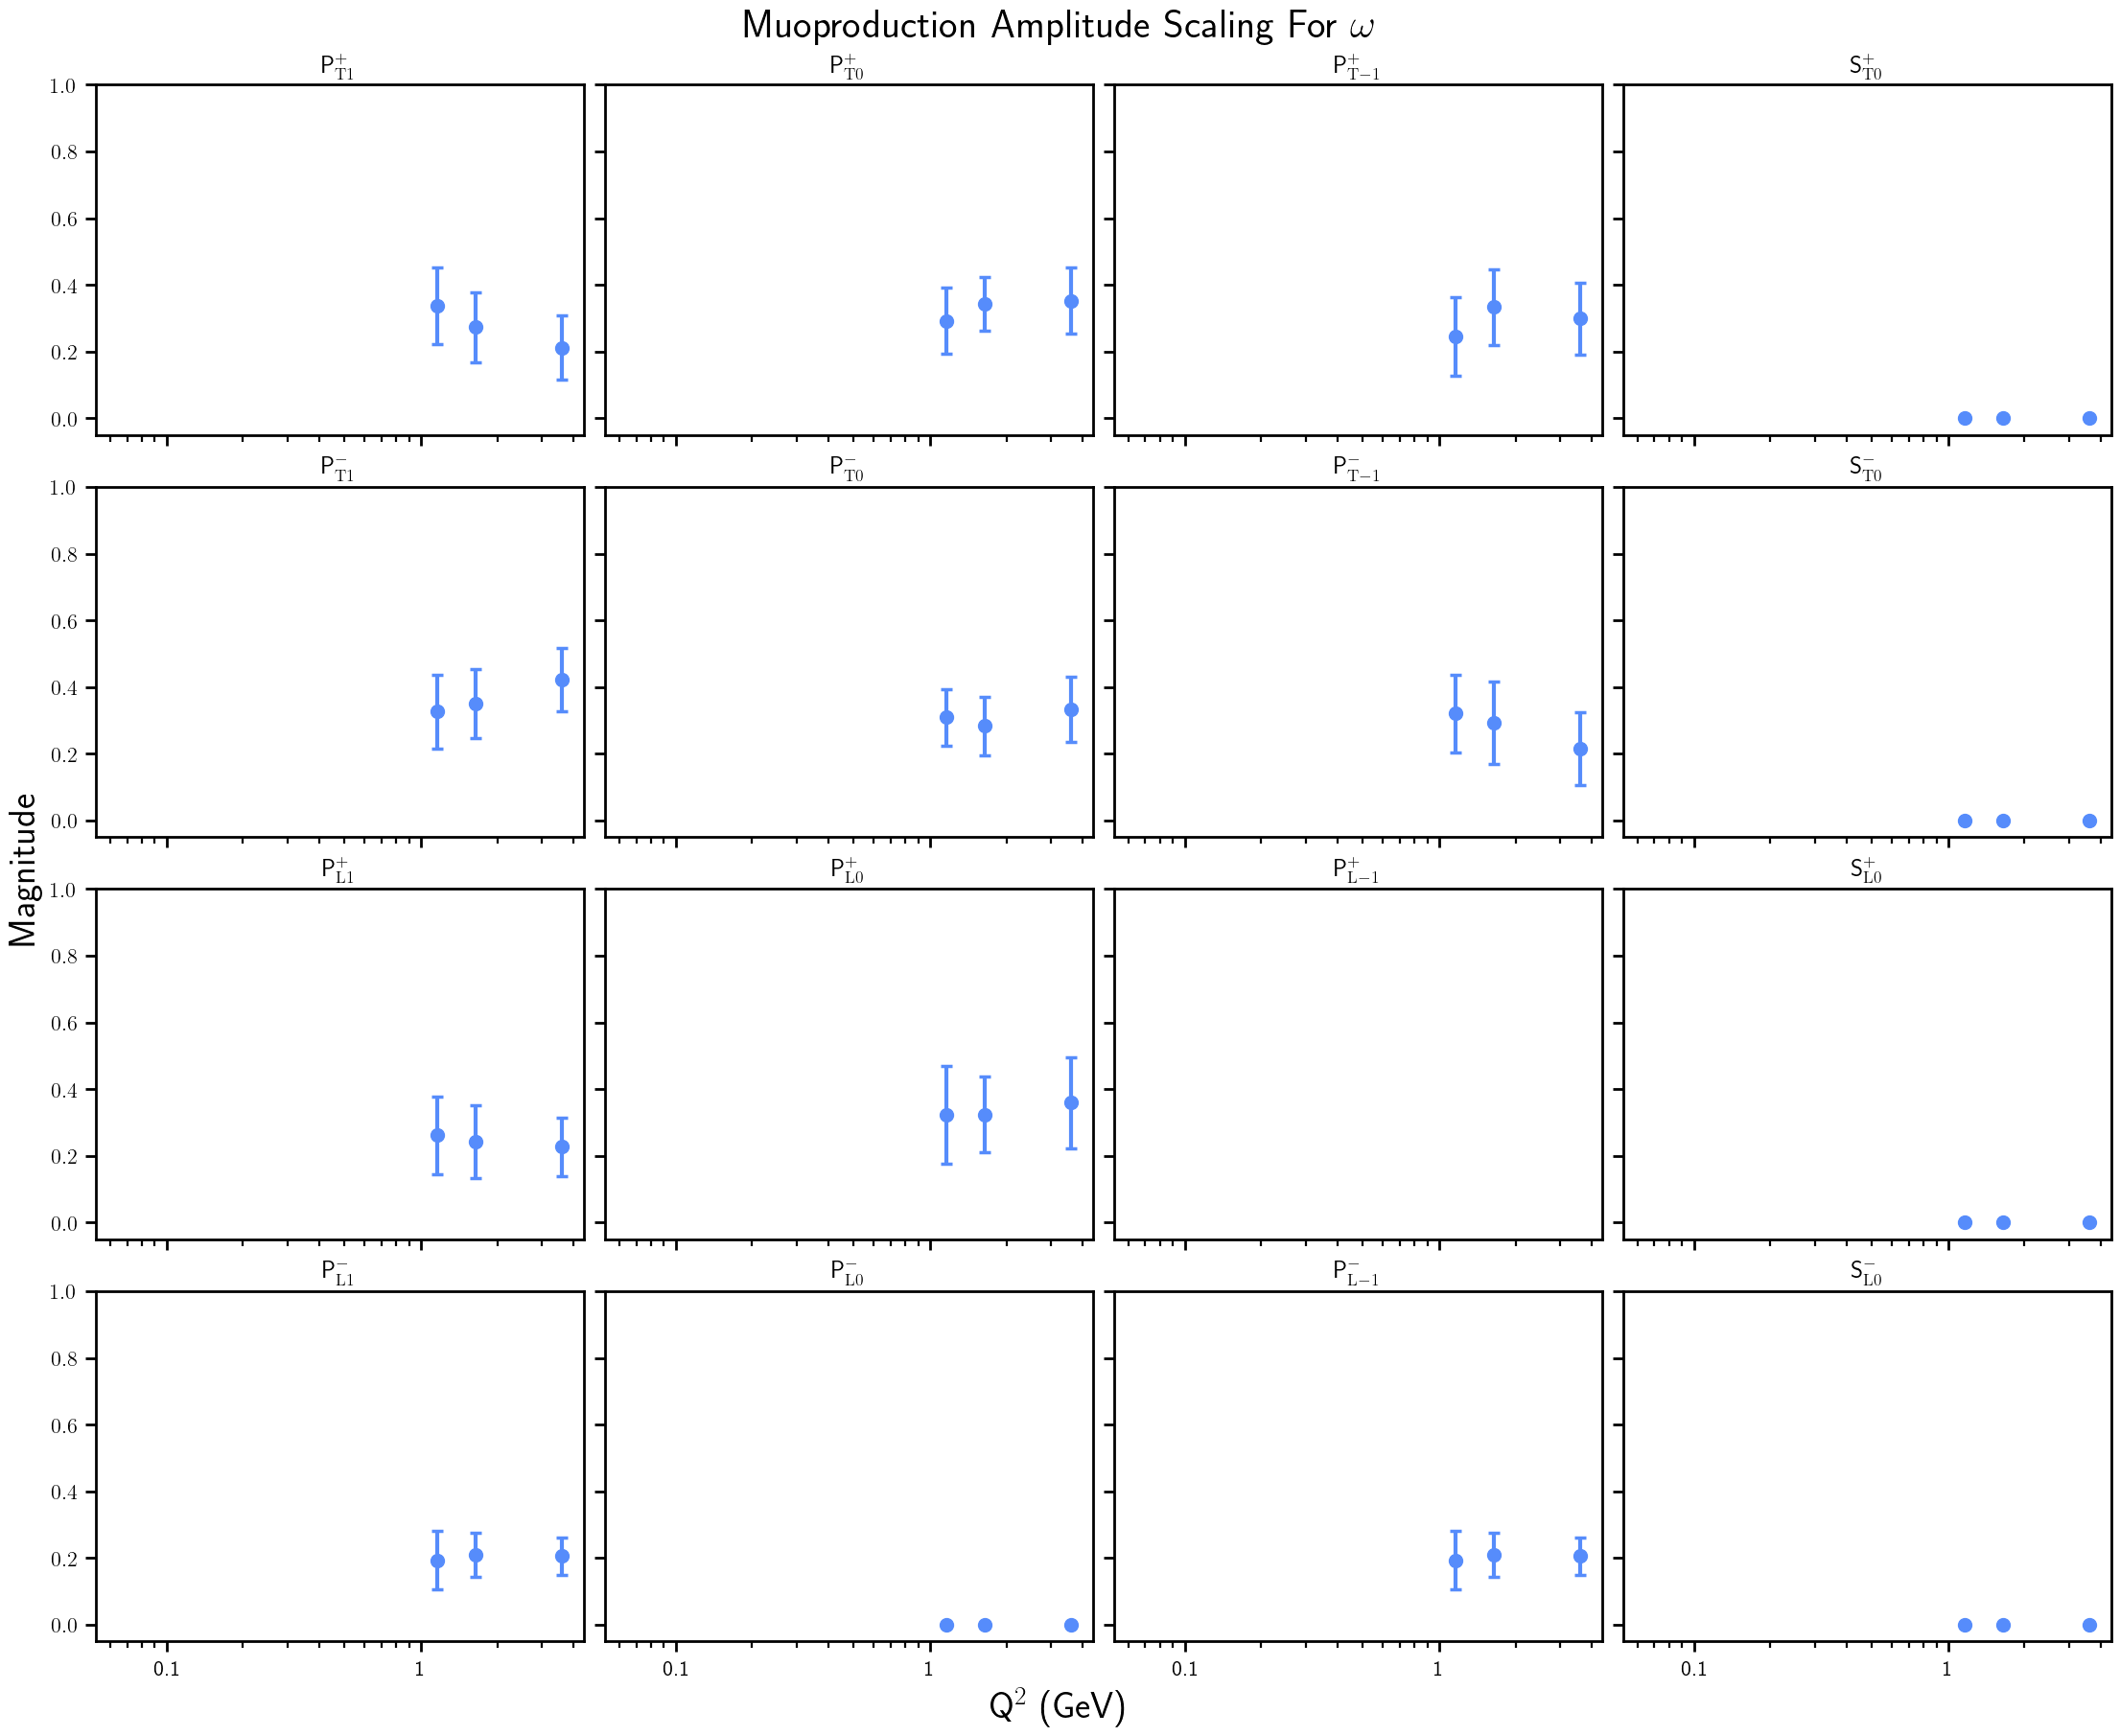

In [18]:
# AMPLITUDE SCALING USING BOOTSTRAP TO GET UNCERTAINTIES
titles = [
    "Electroproduction Amplitude Scaling For $\\rho^0$",
    "Muoproduction Amplitude Scaling For $\\rho^0$",
    "Electroproduction Amplitude Scaling For $\\omega$",
    "Muoproduction Amplitude Scaling For $\\omega$",
]

N = 1000
for r in range(4):
    mags_array = np.empty((bin_size[r], 4, 4))
    phases_array = np.empty((bin_size[r], 4, 4))
    mags_array_err = np.empty((bin_size[r], 4, 4))
    phases_array_err = np.empty((bin_size[r], 4, 4))

    for i in range(bin_size[r]):
        df = ROOT.RDataFrame(
            "PartialWaves",
            "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/"
            + filenames[r] + "_bootstrap_" + str(i) + ".root"
        )

        mags = df.AsNumpy(columns=cols_mag)
        phases = df.AsNumpy(columns=cols_phase)

        for j in range(4):
            for k in range(4):
                y = mags[cols_mag[k + 4 * j]]
                x = phases[cols_phase[k + 4 * j]]

                mean_y = np.mean(y)
                err_y = np.std(y)

                mean_x = circular_mean(x)
                err_x = circular_std(x)

                mags_array[i, j, k] = mean_y
                phases_array[i, j, k] = mean_x

                mags_array_err[i, j, k] = err_y
                phases_array_err[i, j, k] = err_x

    fig, axs = plt.subplots(4, 4, figsize=(22, 18), sharex=True, sharey=True, constrained_layout=True)

    for j in range(4):
        for k in range(4):
            axs[j, k].errorbar(
                Q2[r, :bin_size[r]],
                mags_array[:, j, k],
                yerr=mags_array_err[:, j, k],
                fmt='o',
                markersize=10,
                elinewidth=3.0,
                capsize=4,
                capthick=2.5
            )

            axs[j, k].axis(ymin=-0.05, ymax=1)
            axs[j, k].set_xscale('log')
            axs[j, k].xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:g}'))
            axs[j, k].set_title(ToWave(cols_mag[k + 4 * j]), fontsize=18, pad=10)
            apply_poster_axis_style(axs[j, k], labelsize=16)

    fig.suptitle(titles[r], size=30)
    fig.supylabel("Magnitude", fontsize=28)
    fig.supxlabel("Q$^2$ (GeV)", fontsize=28)
    fig.savefig(
        reaction[r] + "_scaling_poster.png",
        format='png',
        dpi=600,
        bbox_inches='tight'
    )
    plt.show()